In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from weatherdata_rain_wind import WeatherData

In [2]:
save_dir = Path('interpolation_stat')
save_dir.mkdir(exist_ok=True)

In [3]:
grib_path = Path('HARMONIE_AROME_meteo_24hrs/extracted_merged')
first_file = grib_path / "fc2024070912+000GB_UWCW01_N20e_selected.grb"

In [4]:
weather_data = WeatherData(str(grib_path))

In [21]:
# # read the coordinates
# coordinates_df_1 = pd.read_csv('coordinates_storage/coordinates_20250214_154842.csv')
# coordinates_df_2 = pd.read_csv('coordinates_storage/coordinates_20250217_171722.csv')


In [5]:
test_hours = range(16)

In [7]:
def generate_results_df(coordinates_df, weather_data, test_hours=range(16)):
    """
    为给定的坐标集生成插值结果DataFrame
    
    Parameters:
    -----------
    coordinates_df: DataFrame
        包含坐标点的DataFrame
    weather_data: WeatherData object
        天气数据对象
    test_hours: range
        要测试的小时范围
    
    Returns:
    -----------
    DataFrame: 包含所有插值结果的数据框
    """
    results_data = []
    test_coordinates = list(zip(coordinates_df['latitude'], coordinates_df['longitude']))
    
    for hour in test_hours:
        print(f"Processing hour {hour}")
        comparison = weather_data.generate_interpolation_comparison(test_coordinates, hour)
        
        # 组织数据
        for method in ['ground_truth', 'bilinear', 'idw', 'kriging', 'spline', 'rbf']:
            for param in ['wind_u', 'wind_v', 'rain']:
                if method == 'ground_truth':
                    values = comparison[method][param]
                else:
                    values = comparison[method][param]
                
                # 合并数据
                for i, value in enumerate(values):
                    results_data.append({
                        'hour': hour,
                        'method': method,
                        'parameter': param,
                        'value': value,
                        'lat': test_coordinates[i][0],
                        'lon': test_coordinates[i][1]
                    })
    
    return pd.DataFrame(results_data)

# 读取四组坐标数据
coordinates_files = [
    'coordinates_storage/coordinates_20250214_154842.csv',
    # 'coordinates_storage/coordinates_20250217_171722.csv',
    # 'coordinates_storage/coordinates_20250219_012308.csv',
    # 'coordinates_storage/coordinates_20250219_013241.csv'   #这里在需要时再启用，现在只分析阿姆的数据，也就是location1
]

# 读取数据并生成结果
results_dfs = []
for i, file_path in enumerate(coordinates_files, 1):
    print(f"\nProcessing coordinate set {i}...")
    coordinates_df = pd.read_csv(file_path)
    results_df = generate_results_df(coordinates_df, weather_data)
    results_df['dataset'] = f'location_set_{i}'
    results_dfs.append(results_df)

    # 保存单独的结果
    # save_path = save_dir / f'results_location_{i}.csv'
    # results_df.to_csv(save_path, index=False)
    # print(f"Results saved to: {save_path}")
        
    
    
#保存单独的结果
combined_results_df = pd.concat(results_dfs, ignore_index=True)

# 现在我们可以分别分析两组数据，或者合并后一起分析
# 合并数据集（如果需要）
# combined_results_df = pd.concat([results_df_1, results_df_2], ignore_index=True)




Processing coordinate set 1...
Processing hour 0


d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\interpolate\_rbf.py:268: LinAlgWarning: Ill-conditioned matrix (rcond=5.34083e-19): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


Processing hour 1
Processing hour 2
Processing hour 3
Processing hour 4
Processing hour 5
Processing hour 6
Processing hour 7
Processing hour 8
Processing hour 9
Processing hour 10
Processing hour 11
Processing hour 12
Processing hour 13
Processing hour 14
Processing hour 15


## 同一地点（阿姆斯特丹）不同的插值方法是否有显著性差异？


Analyzing spatial-temporal patterns for BILINEAR method:

WIND_U Analysis:

Peak Analysis:

location_1:
Maximum: 11.40 at hour 14
Minimum: -10.61 at hour 7

location_2:
Maximum: 14.18 at hour 7
Minimum: -10.90 at hour 6

location_3:
Maximum: 11.91 at hour 14
Minimum: -15.54 at hour 8

location_4:
Maximum: 11.57 at hour 7
Minimum: -9.67 at hour 5

Volatility Analysis:

location_1:
Standard Deviation: 5.76
Range: 22.01
Coefficient of Variation: 240.39%

location_2:
Standard Deviation: 7.27
Range: 25.09
Coefficient of Variation: 310.74%

location_3:
Standard Deviation: 8.23
Range: 27.45
Coefficient of Variation: -1208.45%

location_4:
Standard Deviation: 5.92
Range: 21.24
Coefficient of Variation: 207.40%

Cross-correlation Analysis:
    location_1_vs_location_2  location_1_vs_location_3  \
-3                  0.716126                  0.636080   
-2                  0.715993                  0.636100   
-1                  0.715850                  0.636120   
0                   0.7156

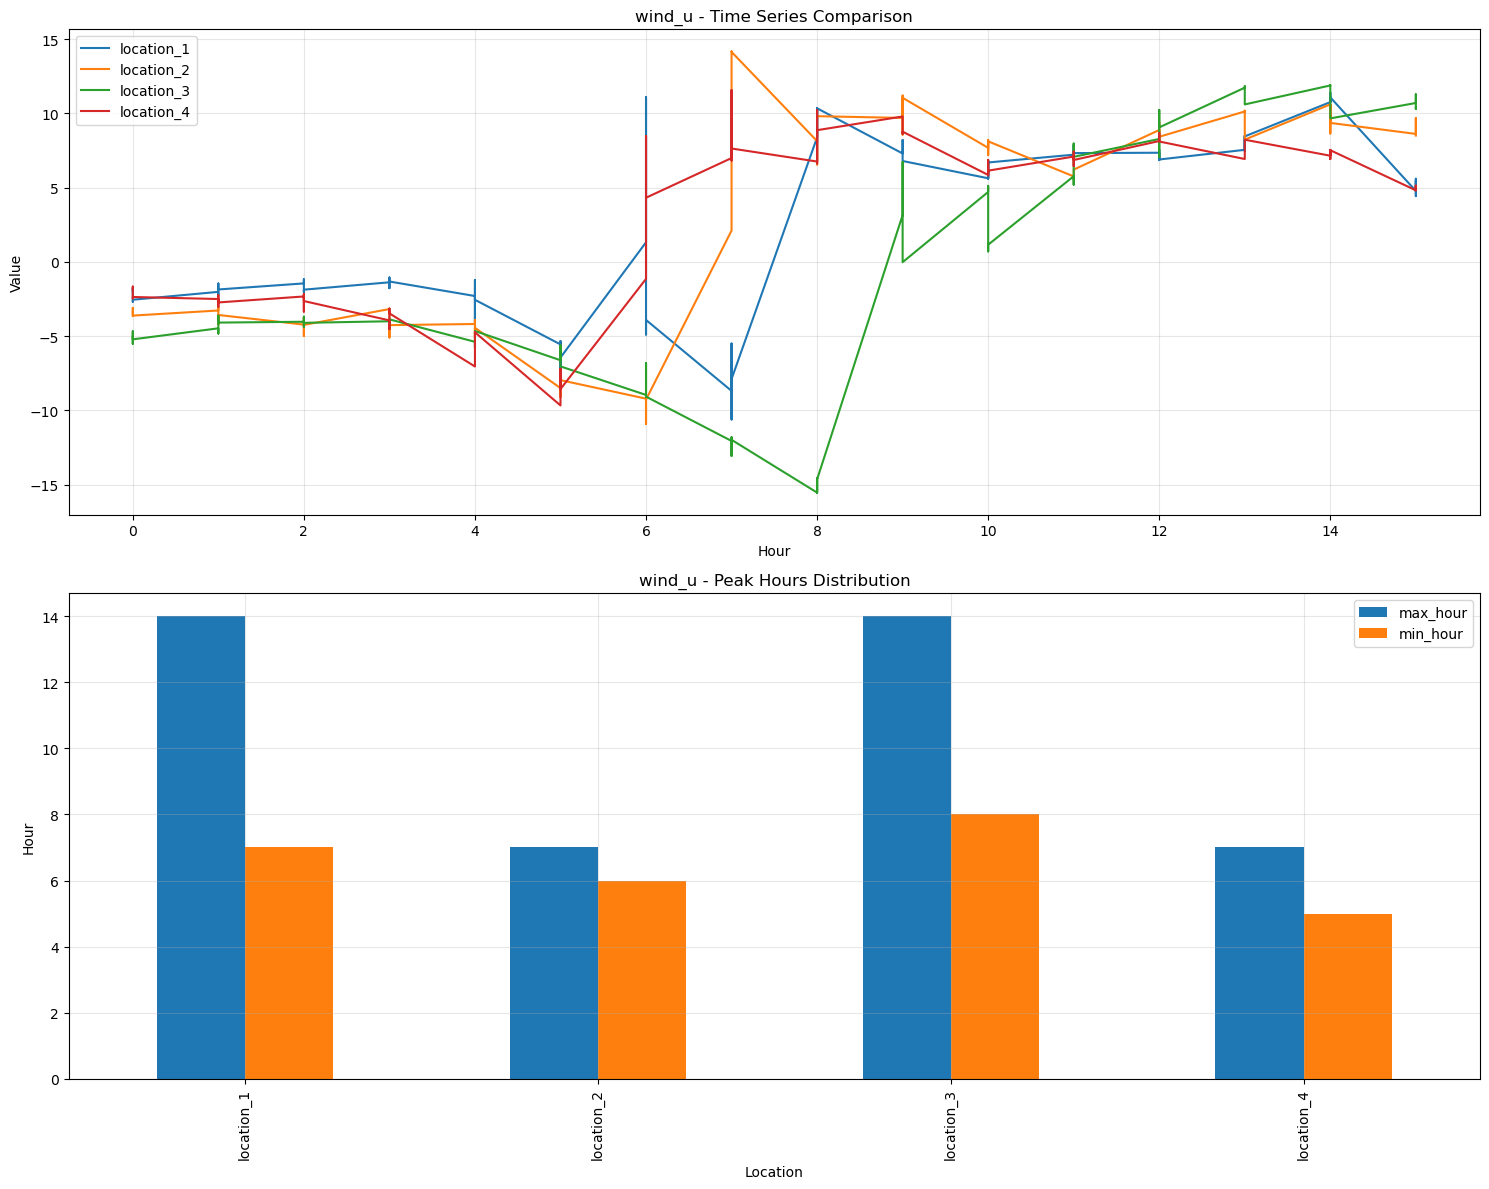


Kruskal-Wallis H-test:
H-statistic: 8220.4305
p-value: 0.0000

WIND_V Analysis:

Peak Analysis:

location_1:
Maximum: 9.02 at hour 15
Minimum: -2.78 at hour 9

location_2:
Maximum: 12.30 at hour 8
Minimum: -1.60 at hour 7

location_3:
Maximum: 26.00 at hour 9
Minimum: 3.06 at hour 6

location_4:
Maximum: 12.37 at hour 8
Minimum: -7.14 at hour 6

Volatility Analysis:

location_1:
Standard Deviation: 2.25
Range: 11.80
Coefficient of Variation: 56.42%

location_2:
Standard Deviation: 1.99
Range: 13.90
Coefficient of Variation: 39.69%

location_3:
Standard Deviation: 4.83
Range: 22.94
Coefficient of Variation: 56.25%

location_4:
Standard Deviation: 3.53
Range: 19.51
Coefficient of Variation: 98.08%

Cross-correlation Analysis:
    location_1_vs_location_2  location_1_vs_location_3  \
-3                 -0.029626                 -0.278352   
-2                 -0.029123                 -0.278427   
-1                 -0.028705                 -0.278525   
0                  -0.028374     

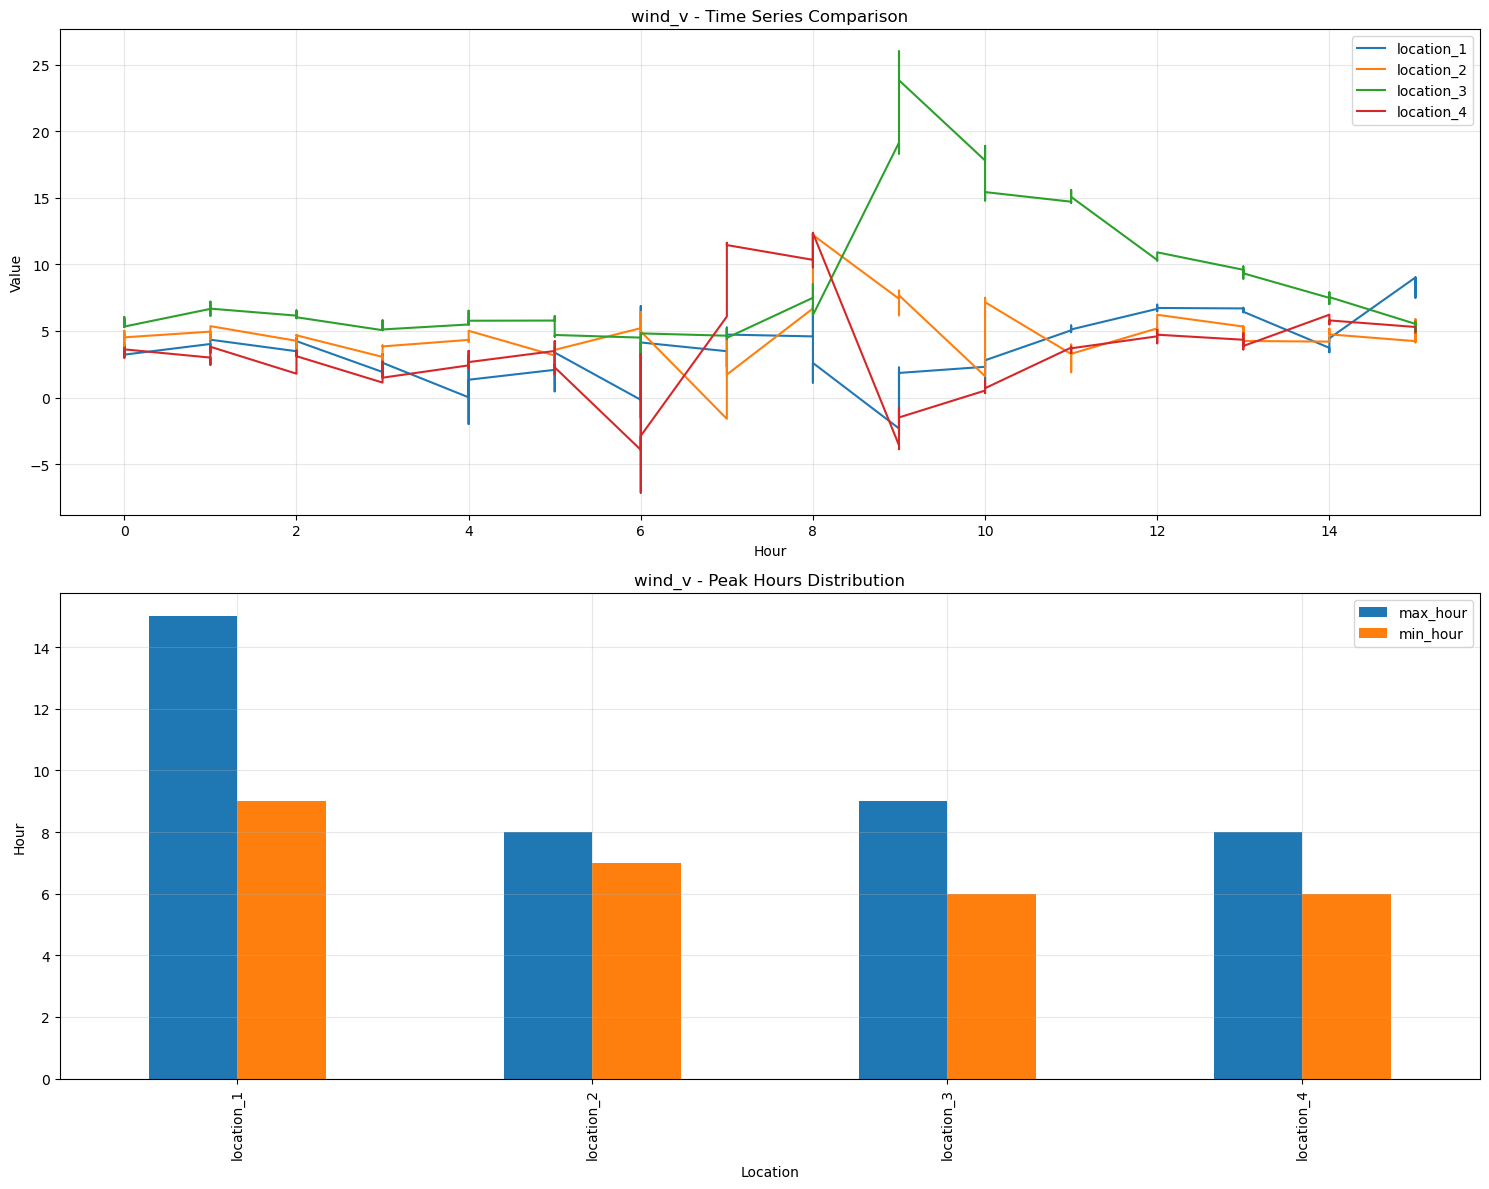


Kruskal-Wallis H-test:
H-statistic: 76874.4695
p-value: 0.0000

RAIN Analysis:

Peak Analysis:

location_1:
Maximum: 16.35 at hour 7
Minimum: 0.00 at hour 0

location_2:
Maximum: 13.03 at hour 7
Minimum: 0.00 at hour 0

location_3:
Maximum: 5.31 at hour 9
Minimum: 0.00 at hour 0

location_4:
Maximum: 15.50 at hour 6
Minimum: 0.00 at hour 0

Volatility Analysis:

location_1:
Standard Deviation: 3.58
Range: 16.35
Coefficient of Variation: 278.93%

location_2:
Standard Deviation: 2.63
Range: 13.03
Coefficient of Variation: 327.39%

location_3:
Standard Deviation: 1.10
Range: 5.31
Coefficient of Variation: 243.78%

location_4:
Standard Deviation: 3.65
Range: 15.50
Coefficient of Variation: 233.91%

Cross-correlation Analysis:
    location_1_vs_location_2  location_1_vs_location_3  \
-3                  0.846085                 -0.135681   
-2                  0.843808                 -0.135851   
-1                  0.841493                 -0.136018   
0                   0.839143       

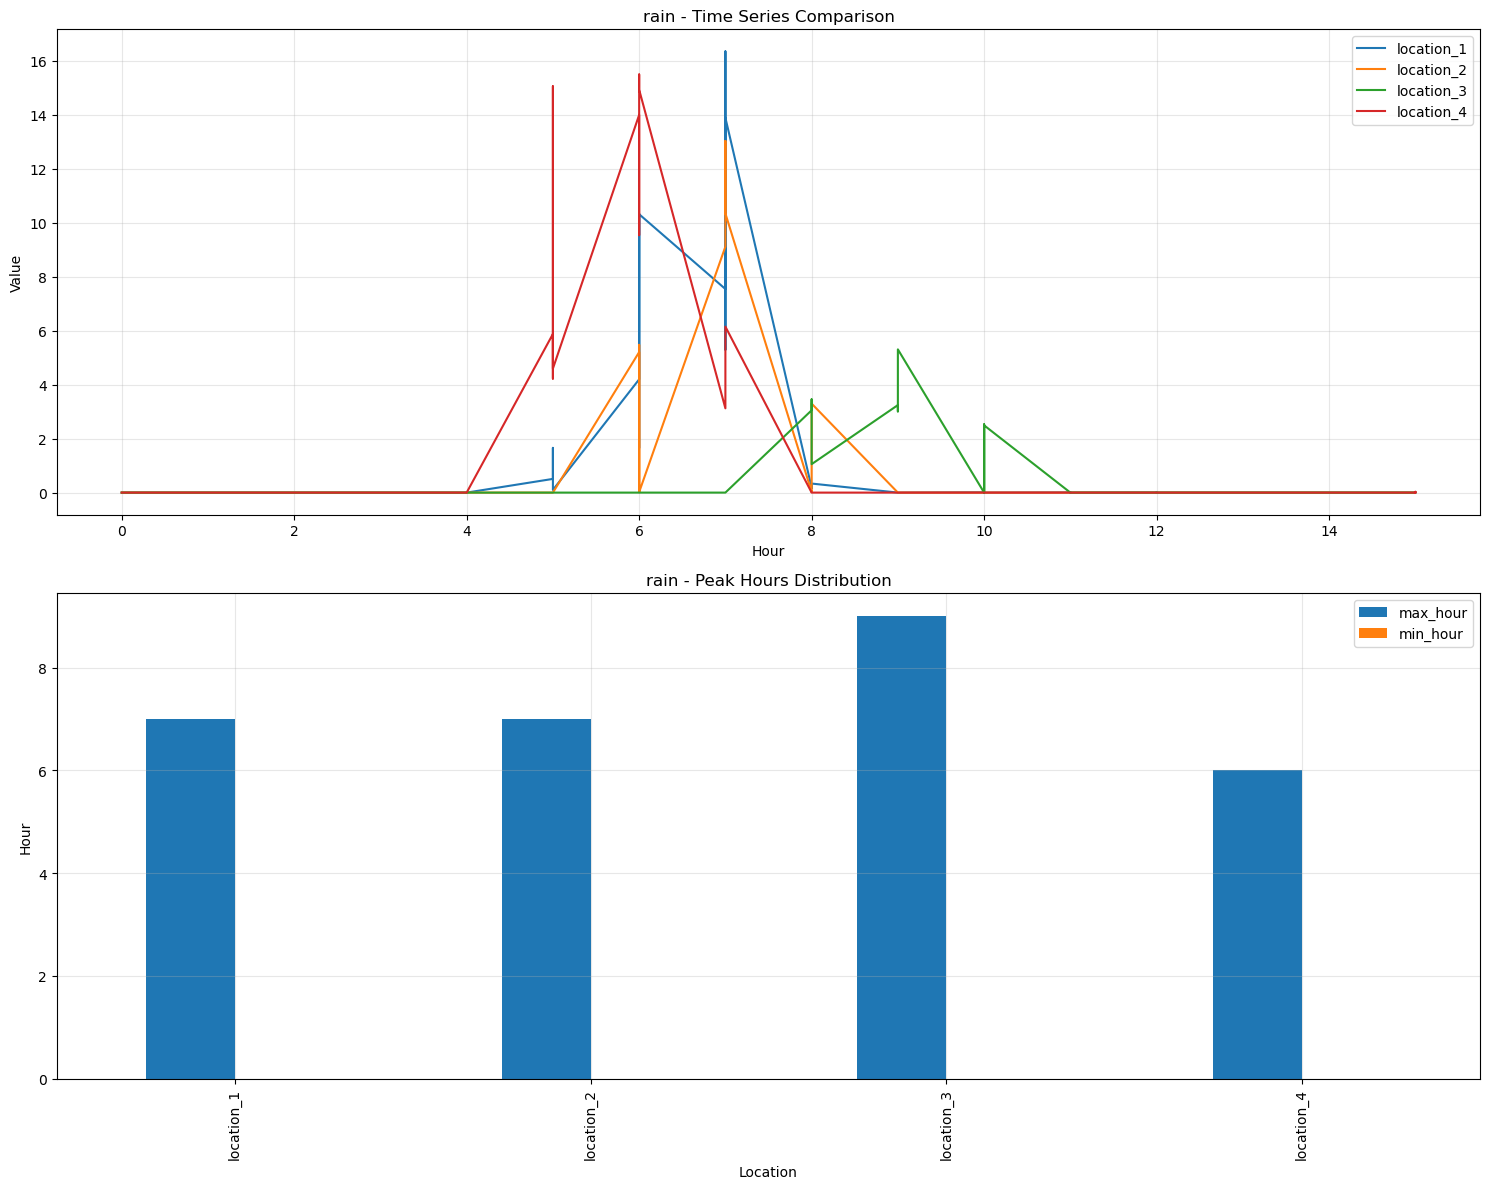


Kruskal-Wallis H-test:
H-statistic: 7863.0423
p-value: 0.0000


In [37]:
def analyze_spatial_temporal_patterns(results_dfs, methods=['kriging']):
    """
    分析不同地点的时空模式差异
    """
    for method in methods:
        print(f"\nAnalyzing spatial-temporal patterns for {method.upper()} method:")
        
        for param in ['wind_u', 'wind_v', 'rain']:
            # 提取每个位置的时间序列
            location_series = []
            for i, df in enumerate(results_dfs, 1):
                series = df[
                    (df['method'] == method) & 
                    (df['parameter'] == param)
                ][['hour', 'value']].set_index('hour')['value']
                location_series.append(series)
            
            # 创建多位置时间序列DataFrame
            data = pd.DataFrame({
                f'location_{i+1}': series 
                for i, series in enumerate(location_series)
            })
            
            print(f"\n{param.upper()} Analysis:")
            
            # 1. 峰值分析
            peaks = {
                f'location_{i+1}': {
                    'max_value': data[f'location_{i+1}'].max(),
                    'max_hour': data[f'location_{i+1}'].idxmax(),
                    'min_value': data[f'location_{i+1}'].min(),
                    'min_hour': data[f'location_{i+1}'].idxmin()
                }
                for i in range(4)
            }
            
            print("\nPeak Analysis:")
            for loc, peak_info in peaks.items():
                print(f"\n{loc}:")
                print(f"Maximum: {peak_info['max_value']:.2f} at hour {peak_info['max_hour']}")
                print(f"Minimum: {peak_info['min_value']:.2f} at hour {peak_info['min_hour']}")
            
            # 2. 波动性分析
            volatility = {
                f'location_{i+1}': {
                    'std': data[f'location_{i+1}'].std(),
                    'range': data[f'location_{i+1}'].max() - data[f'location_{i+1}'].min(),
                    'cv': data[f'location_{i+1}'].std() / data[f'location_{i+1}'].mean() * 100
                }
                for i in range(4)
            }
            
            print("\nVolatility Analysis:")
            for loc, vol_info in volatility.items():
                print(f"\n{loc}:")
                print(f"Standard Deviation: {vol_info['std']:.2f}")
                print(f"Range: {vol_info['range']:.2f}")
                print(f"Coefficient of Variation: {vol_info['cv']:.2f}%")
            
            # 3. 时间滞后相关分析
            print("\nCross-correlation Analysis:")
            max_lag = 3  # 最大时间滞后
            cross_corr = pd.DataFrame(index=range(-max_lag, max_lag+1))
            
            for i in range(4):
                for j in range(i+1, 4):
                    loc1 = f'location_{i+1}'
                    loc2 = f'location_{j+1}'
                    ccf = [data[loc1].corr(data[loc2].shift(lag)) 
                          for lag in range(-max_lag, max_lag+1)]
                    cross_corr[f'{loc1}_vs_{loc2}'] = ccf
            
            print(cross_corr)
            
            # 4. 可视化
            fig, axes = plt.subplots(2, 1, figsize=(15, 12))
            
            # 时间序列对比
            data.plot(ax=axes[0])
            axes[0].set_title(f'{param} - Time Series Comparison')
            axes[0].set_xlabel('Hour')
            axes[0].set_ylabel('Value')
            axes[0].grid(True, alpha=0.3)
            
            # 峰值时间分布
            peak_hours = pd.DataFrame({
                'max_hour': [peaks[f'location_{i+1}']['max_hour'] for i in range(4)],
                'min_hour': [peaks[f'location_{i+1}']['min_hour'] for i in range(4)]
            }, index=[f'location_{i+1}' for i in range(4)])
            
            peak_hours.plot(kind='bar', ax=axes[1])
            axes[1].set_title(f'{param} - Peak Hours Distribution')
            axes[1].set_xlabel('Location')
            axes[1].set_ylabel('Hour')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # 5. 统计显著性检验
            # 使用Kruskal-Wallis H-test（非参数方法）
            h_stat, p_value = stats.kruskal(*[data[col] for col in data.columns])
            print("\nKruskal-Wallis H-test:")
            print(f"H-statistic: {h_stat:.4f}")
            print(f"p-value: {p_value:.4f}")

# 执行分析
analyze_spatial_temporal_patterns(results_dfs, methods=['bilinear'])

## 确定每个位置不同插值方式的表现


In [38]:
def compare_interpolation_methods_by_location(results_dfs, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    比较每个位置不同插值方法的表现
    """
    for i, df in enumerate(results_dfs, 1):
        print(f"\nLocation {i} Analysis:")
        
        for param in ['wind_u', 'wind_v', 'rain']:
            print(f"\n{param.upper()}:")
            
            # 获取真实值
            truth = df[
                (df['parameter'] == param) & 
                (df['method'] == 'ground_truth')
            ]['value'].values
            
            # 计算每种方法的误差指标
            method_metrics = {}
            for method in methods:
                pred = df[
                    (df['parameter'] == param) & 
                    (df['method'] == method)
                ]['value'].values
                
                # 计算多个误差指标
                rmse = np.sqrt(np.mean((pred - truth)**2))
                mae = np.mean(np.abs(pred - truth))
                mape = np.mean(np.abs((pred - truth) / truth)) * 100 if not np.any(truth == 0) else np.nan
                r2 = stats.pearsonr(truth, pred)[0]**2
                
                method_metrics[method] = {
                    'RMSE': rmse,
                    'MAE': mae,
                    'MAPE': mape,
                    'R2': r2
                }
            
            # 转换为DataFrame并打印
            metrics_df = pd.DataFrame(method_metrics).T
            print("\nError Metrics:")
            print(metrics_df)
            
            # 找出最佳方法
            best_method = {
                'RMSE': metrics_df['RMSE'].idxmin(),
                'MAE': metrics_df['MAE'].idxmin(),
                'R2': metrics_df['R2'].idxmax()
            }
            print("\nBest Methods:")
            for metric, method in best_method.items():
                print(f"{metric}: {method}")

# 执行分析
compare_interpolation_methods_by_location(results_dfs)


Location 1 Analysis:

WIND_U:

Error Metrics:
              RMSE       MAE       MAPE        R2
bilinear  0.318911  0.126039   4.236414  0.996956
idw       0.319755  0.121071   3.996455  0.996941
kriging   0.819505  0.344859  10.044634  0.980039
spline    0.334215  0.136757   4.775263  0.996656
rbf       1.521677  0.498675  17.705377  0.935120

Best Methods:
RMSE: bilinear
MAE: idw
R2: bilinear

WIND_V:

Error Metrics:
              RMSE       MAE       MAPE        R2
bilinear  0.277775  0.140426  10.720020  0.985186
idw       0.284794  0.138717  10.778800  0.984737
kriging   0.679219  0.382873  24.998339  0.914180
spline    0.288771  0.149259  11.391449  0.983952
rbf       1.098809  0.482379  30.196239  0.804391

Best Methods:
RMSE: bilinear
MAE: idw
R2: bilinear

RAIN:

Error Metrics:
              RMSE       MAE  MAPE        R2
bilinear  0.269602  0.075917   NaN  0.994424
idw       0.262739  0.069157   NaN  0.994701
kriging   0.663905  0.213513   NaN  0.968109
spline    0.275342  0

In [39]:
def analyze_terrain_suitability(results_dfs, coordinates_files):
    """
    分析地形特征与插值方法性能的关系
    """
    for i, (df, coord_file) in enumerate(zip(results_dfs, coordinates_files), 1):
        print(f"\nLocation {i} Terrain Analysis:")
        
        # 读取坐标数据
        coords = pd.read_csv(coord_file)
        
        # 计算坐标点的空间分布特征
        spatial_stats = {
            'lat_range': coords['latitude'].max() - coords['latitude'].min(),
            'lon_range': coords['longitude'].max() - coords['longitude'].min(),
            'point_density': len(coords) / (coords['latitude'].max() - coords['latitude'].min()) / \
                           (coords['longitude'].max() - coords['longitude'].min())
        }
        
        print("\nSpatial Characteristics:")
        for key, value in spatial_stats.items():
            print(f"{key}: {value:.4f}")
        
        # 分析每种插值方法的表现
        for param in ['wind_u', 'wind_v', 'rain']:
            print(f"\n{param.upper()} Method Performance:")
            
            truth = df[
                (df['parameter'] == param) & 
                (df['method'] == 'ground_truth')
            ]['value'].values
            
            # 计算空间自相关性
            for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
                pred = df[
                    (df['parameter'] == param) & 
                    (df['method'] == method)
                ]['value'].values
                
                # 计算误差的空间分布特征
                errors = np.abs(pred - truth)
                error_stats = {
                    'mean_error': np.mean(errors),
                    'error_std': np.std(errors),
                    'error_spatial_consistency': np.corrcoef(errors[:-1], errors[1:])[0,1]
                }
                
                print(f"\n{method.upper()}:")
                for key, value in error_stats.items():
                    print(f"{key}: {value:.4f}")

# 执行分析
analyze_terrain_suitability(results_dfs, coordinates_files)


Location 1 Terrain Analysis:

Spatial Characteristics:
lat_range: 0.0934
lon_range: 0.1526
point_density: 287425.2787

WIND_U Method Performance:

BILINEAR:
mean_error: 0.1260
error_std: 0.2929
error_spatial_consistency: 0.9332

IDW:
mean_error: 0.1211
error_std: 0.2959
error_spatial_consistency: 0.8757

KRIGING:
mean_error: 0.3449
error_std: 0.7434
error_spatial_consistency: 0.9402

SPLINE:
mean_error: 0.1368
error_std: 0.3050
error_spatial_consistency: 0.9074

RBF:
mean_error: 0.4987
error_std: 1.4376
error_spatial_consistency: 0.5707

WIND_V Method Performance:

BILINEAR:
mean_error: 0.1404
error_std: 0.2397
error_spatial_consistency: 0.9190

IDW:
mean_error: 0.1387
error_std: 0.2487
error_spatial_consistency: 0.8695

KRIGING:
mean_error: 0.3829
error_std: 0.5610
error_spatial_consistency: 0.9219

SPLINE:
mean_error: 0.1493
error_std: 0.2472
error_spatial_consistency: 0.9015

RBF:
mean_error: 0.4824
error_std: 0.9873
error_spatial_consistency: 0.5436

RAIN Method Performance:

BILI

In [40]:
def analyze_method_stability(results_dfs):
    """
    分析不同插值方法的稳定性
    """
    methods = ['bilinear', 'idw', 'kriging', 'spline', 'rbf']
    
    for param in ['wind_u', 'wind_v', 'rain']:
        print(f"\n{param.upper()} Stability Analysis:")
        
        # 计算每种方法在不同位置的变异系数
        stability_metrics = {}
        for method in methods:
            method_values = []
            method_errors = []
            
            for df in results_dfs:
                # 获取预测值和真实值
                pred = df[
                    (df['parameter'] == param) & 
                    (df['method'] == method)
                ]['value'].values
                
                truth = df[
                    (df['parameter'] == param) & 
                    (df['method'] == 'ground_truth')
                ]['value'].values
                
                method_values.append(pred)
                method_errors.append(np.abs(pred - truth))
            
            # 计算稳定性指标
            stability_metrics[method] = {
                'cv_predictions': np.std(method_values) / np.mean(method_values) * 100,
                'cv_errors': np.std(method_errors) / np.mean(method_errors) * 100,
                'max_error_ratio': np.max(method_errors) / np.min(method_errors)
            }
        
        # 转换为DataFrame并打印
        stability_df = pd.DataFrame(stability_metrics).T
        print("\nStability Metrics:")
        print(stability_df)
        
        # 推荐最稳定的方法
        best_stable = stability_df['cv_errors'].idxmin()
        print(f"\nMost stable method: {best_stable}")

# 执行分析
analyze_method_stability(results_dfs)


WIND_U Stability Analysis:

Stability Metrics:
          cv_predictions   cv_errors  max_error_ratio
bilinear      405.995599  195.056601     1.322122e+07
idw           405.160115  206.621855     1.337893e+08
kriging       403.761436  181.914330     5.466115e+07
spline        406.123346  187.478176     1.252236e+07
rbf           409.329030  256.686467     8.148130e+05

Most stable method: kriging

WIND_V Stability Analysis:

Stability Metrics:
          cv_predictions   cv_errors  max_error_ratio
bilinear       73.372244  177.679227     6.420069e+06
idw            73.278118  188.331029     2.030244e+08
kriging        72.335408  155.314281     1.304817e+05
spline         73.422331  171.490562     4.821687e+07
rbf            74.817468  232.332107     8.293038e+05

Most stable method: kriging

RAIN Stability Analysis:


C:\Users\96454\AppData\Local\Temp\ipykernel_50540\708401128.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  'max_error_ratio': np.max(method_errors) / np.min(method_errors)



Stability Metrics:
          cv_predictions   cv_errors  max_error_ratio
bilinear      288.733341  375.138537              inf
idw           287.990491  397.483493              inf
kriging       280.310727  323.571787              inf
spline        289.708351  369.565490              inf
rbf           294.093239  406.834230              inf

Most stable method: kriging


In [41]:
def perform_anova_analysis(results_dfs, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    使用单因素方差分析和事后检验评估位置间的插值性能差异
    """
    for method in methods:
        print(f"\n{method.upper()} Method Analysis:")
        
        for param in ['wind_u', 'wind_v', 'rain']:
            print(f"\n{param.upper()}:")
            
            # 收集每个位置的误差数据
            location_errors = []
            for df in results_dfs:
                truth = df[
                    (df['parameter'] == param) & 
                    (df['method'] == 'ground_truth')
                ]['value'].values
                
                pred = df[
                    (df['parameter'] == param) & 
                    (df['method'] == method)
                ]['value'].values
                
                errors = np.abs(pred - truth)
                location_errors.append(errors)
            
            # 执行单因素方差分析
            f_stat, p_value = stats.f_oneway(*location_errors)
            
            print("\nOne-way ANOVA results:")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"p-value: {p_value:.4f}")
            
            # 如果ANOVA显示显著差异，进行Tukey HSD事后检验
            if p_value < 0.05:
                # 准备数据进行Tukey检验
                data = []
                labels = []
                for i, errors in enumerate(location_errors, 1):
                    data.extend(errors)
                    labels.extend(['Location ' + str(i)] * len(errors))
                
                # 创建DataFrame
                df_tukey = pd.DataFrame({
                    'Error': data,
                    'Location': labels
                })
                
                # 执行Tukey HSD检验
                from statsmodels.stats.multicomp import pairwise_tukeyhsd
                tukey = pairwise_tukeyhsd(df_tukey['Error'], df_tukey['Location'])
                
                print("\nTukey HSD Post-hoc Analysis:")
                print(tukey)
                
                # 计算效应量（Cohen's d）
                print("\nEffect Sizes (Cohen's d):")
                for i in range(len(location_errors)):
                    for j in range(i+1, len(location_errors)):
                        d = (np.mean(location_errors[i]) - np.mean(location_errors[j])) / \
                            np.sqrt((np.var(location_errors[i]) + np.var(location_errors[j])) / 2)
                        print(f"Location {i+1} vs Location {j+1}: {d:.4f}")
            
            # 描述性统计
            print("\nDescriptive Statistics:")
            for i, errors in enumerate(location_errors, 1):
                print(f"\nLocation {i}:")
                print(f"Mean Error: {np.mean(errors):.4f}")
                print(f"Std Error: {np.std(errors):.4f}")
                print(f"95% CI: [{np.percentile(errors, 2.5):.4f}, {np.percentile(errors, 97.5):.4f}]")

# 执行分析
perform_anova_analysis(results_dfs)


BILINEAR Method Analysis:

WIND_U:

One-way ANOVA results:
F-statistic: 517.8353
p-value: 0.0000

Tukey HSD Post-hoc Analysis:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj  lower   upper  reject
-----------------------------------------------------------
Location 1 Location 2  -0.0214   0.0 -0.0243 -0.0186   True
Location 1 Location 3  -0.0424   0.0 -0.0453 -0.0396   True
Location 1 Location 4  -0.0292   0.0  -0.032 -0.0263   True
Location 2 Location 3   -0.021   0.0 -0.0238 -0.0182   True
Location 2 Location 4  -0.0077   0.0 -0.0106 -0.0049   True
Location 3 Location 4   0.0133   0.0  0.0105  0.0161   True
-----------------------------------------------------------

Effect Sizes (Cohen's d):
Location 1 vs Location 2: 0.0899
Location 1 vs Location 3: 0.1860
Location 1 vs Location 4: 0.1224
Location 2 vs Location 3: 0.1381
Location 2 vs Location 4: 0.0463
Location 3 vs Location 4: -0.0875

Descriptive Statistics:

Location 1:
Mean Err

## 下一章节


In [10]:
## 论文已采用表格 Table 5 1 Error Metrics for Meteorological Parameter Interpolation Methods

def calculate_error_metrics(df, param):
    """计算各种误差指标"""
    # 获取真实值
    truth = df[df['method'] == 'ground_truth']['value'].values
    metrics = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = df[df['method'] == method]['value'].values
        metrics[method] = {
            'MAE': np.mean(np.abs(pred - truth)),
            'RMSE': np.sqrt(np.mean((pred - truth)**2)),
            'R2': stats.pearsonr(truth, pred)[0]**2,
            'Bias': np.mean(pred - truth)
        }
    
    return pd.DataFrame(metrics).T

# 分别计算每个参数的误差统计
for param in ['wind_u', 'wind_v', 'rain']:
    param_data = results_df[results_df['parameter'] == param]
    print(f"\n{param} Error Metrics:")
    print(calculate_error_metrics(param_data, param))


wind_u Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.126039  0.318911  0.996956 -0.001863
idw       0.121071  0.319755  0.996941 -0.008320
kriging   0.344859  0.819505  0.980039 -0.050829
spline    0.136757  0.334215  0.996656  0.002056
rbf       0.498675  1.521677  0.935120  0.025259

wind_v Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.140426  0.277775  0.985186 -0.000224
idw       0.138717  0.284794  0.984737  0.003298
kriging   0.382873  0.679219  0.914180 -0.020804
spline    0.149259  0.288771  0.983952  0.007267
rbf       0.482379  1.098809  0.804391  0.000393

rain Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.075917  0.269602  0.994424 -0.000704
idw       0.069157  0.262739  0.994701  0.004461
kriging   0.213513  0.663905  0.968109 -0.030653
spline    0.078079  0.275342  0.994199  0.005708
rbf       0.209390  0.818692  0.952373  0.019001


In [12]:


# 2. 可视化分析
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表样式
plt.style.use('default')  # 使用默认样式
sns.set_theme(style="whitegrid")  # 使用seaborn的网格样式

# 创建子图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 设置颜色方案
colors = sns.color_palette("husl", n_colors=6)

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 箱线图比较
    sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
    
    # 设置标题和标签
    axes[i].set_title(f'{param} Distribution by Method', fontsize=12, pad=10)
    axes[i].set_xlabel('Interpolation Method', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    
    # 添加网格
    axes[i].grid(True, linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig(save_dir / 'distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# 添加更多的可视化分析
# 1. 误差分布图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 计算每种方法的误差
    truth = param_data[param_data['method'] == 'ground_truth']['value'].values
    errors = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = param_data[param_data['method'] == method]['value'].values
        errors[method] = pred - truth
    
    # 绘制误差分布
    error_data = pd.DataFrame(errors)
    sns.violinplot(data=error_data, ax=axes[i], palette=colors)
    
    axes[i].set_title(f'{param} Error Distribution', fontsize=12, pad=10)
    axes[i].set_xlabel('Method', fontsize=10)
    axes[i].set_ylabel('Error', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # 添加零线
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(save_dir / 'error_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. 散点图比较（真实值vs预测值）
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    truth = param_data[param_data['method'] == 'ground_truth']['value'].values
    
    for j, method in enumerate(['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
        pred = param_data[param_data['method'] == method]['value'].values
        
        # 绘制散点图
        axes[i, j].scatter(truth, pred, alpha=0.1, s=1)
        
        # 添加对角线
        min_val = min(truth.min(), pred.min())
        max_val = max(truth.max(), pred.max())
        axes[i, j].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        
        axes[i, j].set_title(f'{param} - {method}')
        axes[i, j].set_xlabel('Ground Truth')
        axes[i, j].set_ylabel('Predicted')
        axes[i, j].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(save_dir / 'scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2895448660.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2895448660.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2895448660.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C

wind_u mean value: 2.3994062915444374


C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='method', y='value', data=centered_df, ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')


wind_v mean value: 3.9796977043151855


C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='method', y='value', data=centered_df, ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')


rain mean value: 1.2857182174921036


C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='method', y='value', data=centered_df, ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_80696\2122518385.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')


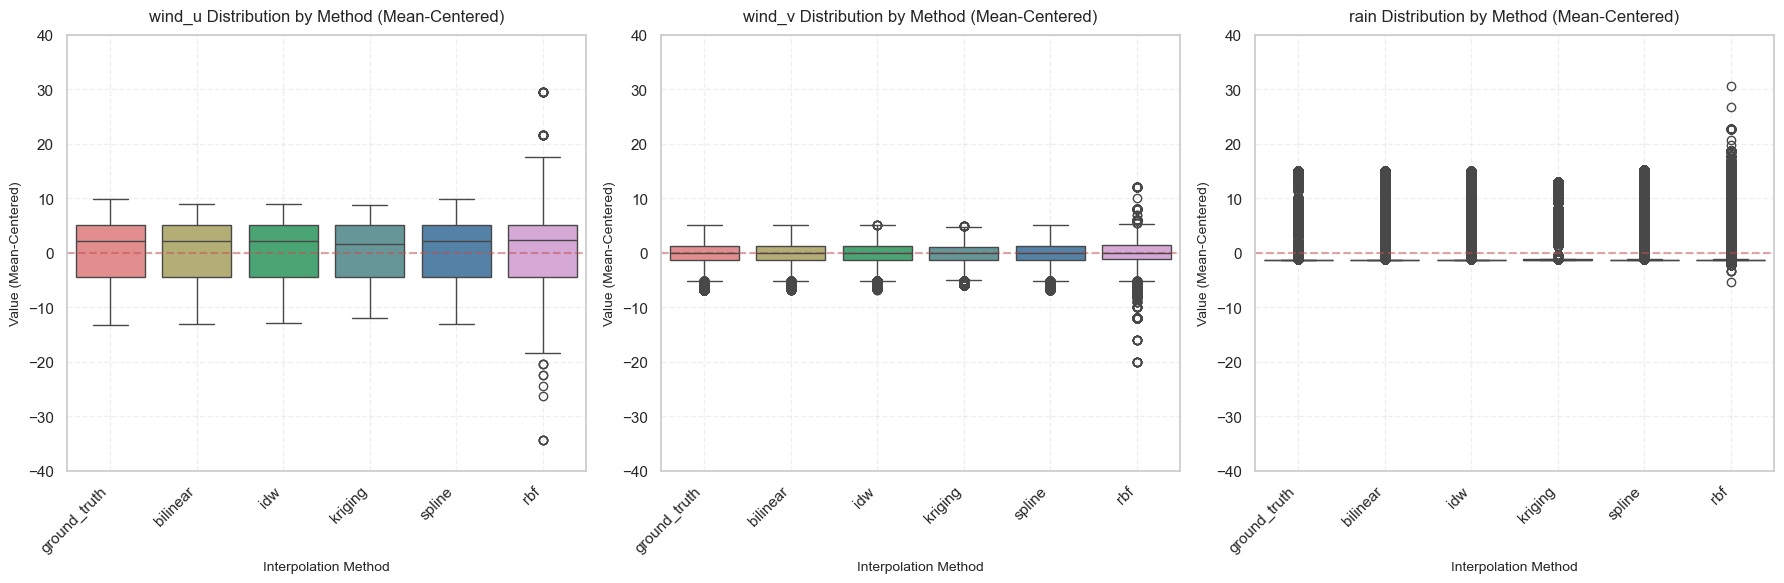

In [13]:
## 论文已经采用图表 Figure 5 2 Distribution of Interpolated Values by Methods.


# 统一y轴范围并进行均值中心化处理的分布比较图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 定义颜色方案
colors = {
    'ground_truth': 'lightcoral',
    'bilinear': 'darkkhaki',
    'idw': 'mediumseagreen',
    'kriging': 'cadetblue',
    'spline': 'steelblue',
    'rbf': 'plum'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 定义统一的y轴范围
y_min, y_max = -40, 40

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 获取ground_truth数据
    truth_data = param_data[param_data['method'] == 'ground_truth']
    
    # 计算ground_truth的均值，用于中心化
    truth_mean = truth_data['value'].mean()
    print(f"{param} mean value: {truth_mean}")
    
    # 创建一个新的DataFrame来存储中心化后的数据
    centered_data = []
    
    # 对每种方法的数据进行中心化处理
    for method in ['ground_truth', 'bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        method_data = param_data[param_data['method'] == method].copy()
        
        # 中心化处理：减去ground_truth的均值
        method_data['value'] = method_data['value'] - truth_mean
        
        # 添加到中心化数据集
        centered_data.append(method_data)
    
    # 合并所有中心化后的数据
    centered_df = pd.concat(centered_data)
    
    # 使用箱线图展示分布
    sns.boxplot(x='method', y='value', data=centered_df, ax=axes[i], palette=colors)
    
    # 设置标题和标签
    axes[i].set_title(f'{param} Distribution by Method (Mean-Centered)', fontsize=12, pad=10)
    axes[i].set_xlabel('Interpolation Method', fontsize=10)
    axes[i].set_ylabel('Value (Mean-Centered)', fontsize=10)
    
    # 设置统一的y轴范围
    axes[i].set_ylim(y_min, y_max)
    
    # 添加零线（代表均值）
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    
    # 添加网格线
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    # 优化x轴标签
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()  # 直接显示图表，不保存文件

In [17]:
# time series analysis
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 计算每个小时的平均值
    hourly_means = param_data.groupby(['hour', 'method'])['value'].mean().unstack()
    
    # 绘制时间序列
    hourly_means.plot(ax=axes[i], marker='o')
    axes[i].set_title(f'{param} Temporal Evolution')
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig(save_dir / 'temporal_evolution2.png')
plt.close()

 

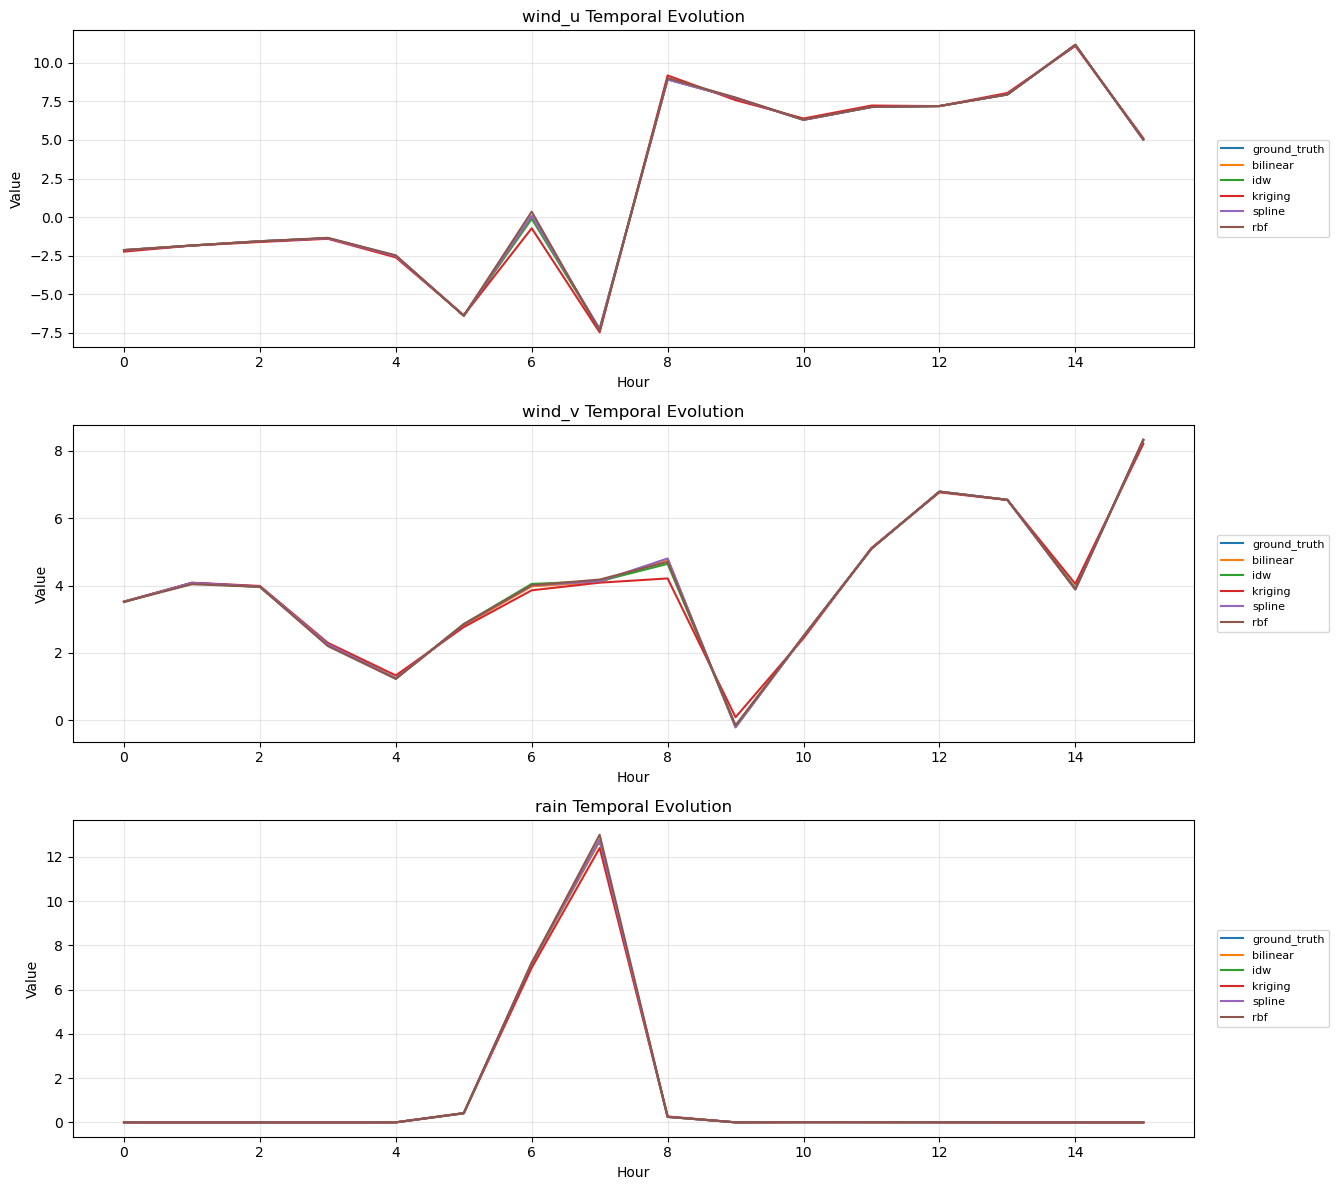

In [8]:
#上一个时间序列的调整版 （仅阿姆的时序分析）（论文已采用）
def plot_temporal_evolution(results_df, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    绘制时间序列演变图，只显示纯折线
    """
    # 为每个参数创建单独的子图
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    parameters = ['wind_u', 'wind_v', 'rain']
    
    for ax, param in zip(axes, parameters):
        # 获取参数数据
        param_data = results_df[results_df['parameter'] == param]
        
        # 绘制每种方法的时间序列，只使用纯折线
        for method in ['ground_truth'] + methods:
            method_data = param_data[param_data['method'] == method]
            # 计算每个时间点的平均值
            mean_data = method_data.groupby('hour')['value'].mean()
            
            ax.plot(mean_data.index, mean_data.values, 
                   label=method,
                   linewidth=1.5)  # 只画折线，不包含任何其他元素
        
        # 设置标题和标签
        ax.set_title(f'{param} Temporal Evolution')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # 优化图例显示
        ax.legend(
            fontsize=8,
            framealpha=0.8,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            ncol=1,
            borderaxespad=0.
        )
    
    # 调整子图布局
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    
    # 显示图表
    plt.show()

# 调用函数
plot_temporal_evolution(results_df)

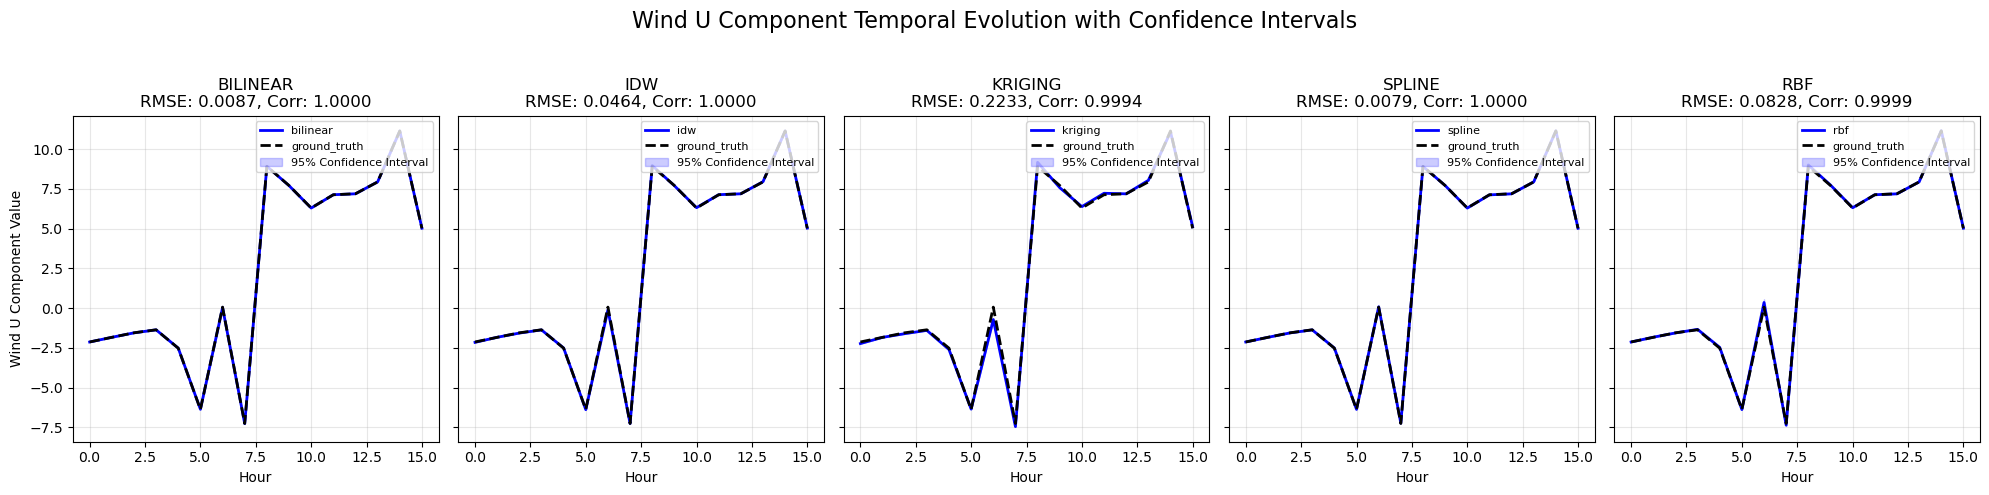

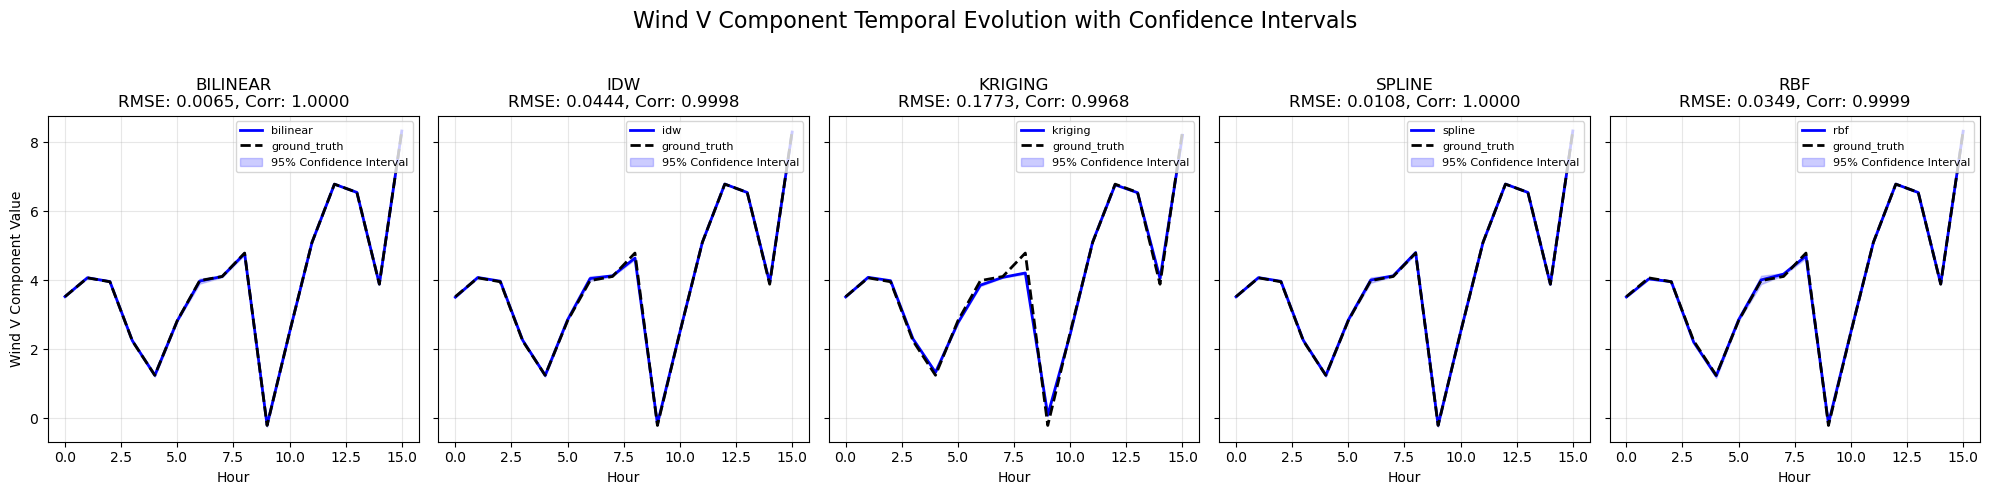

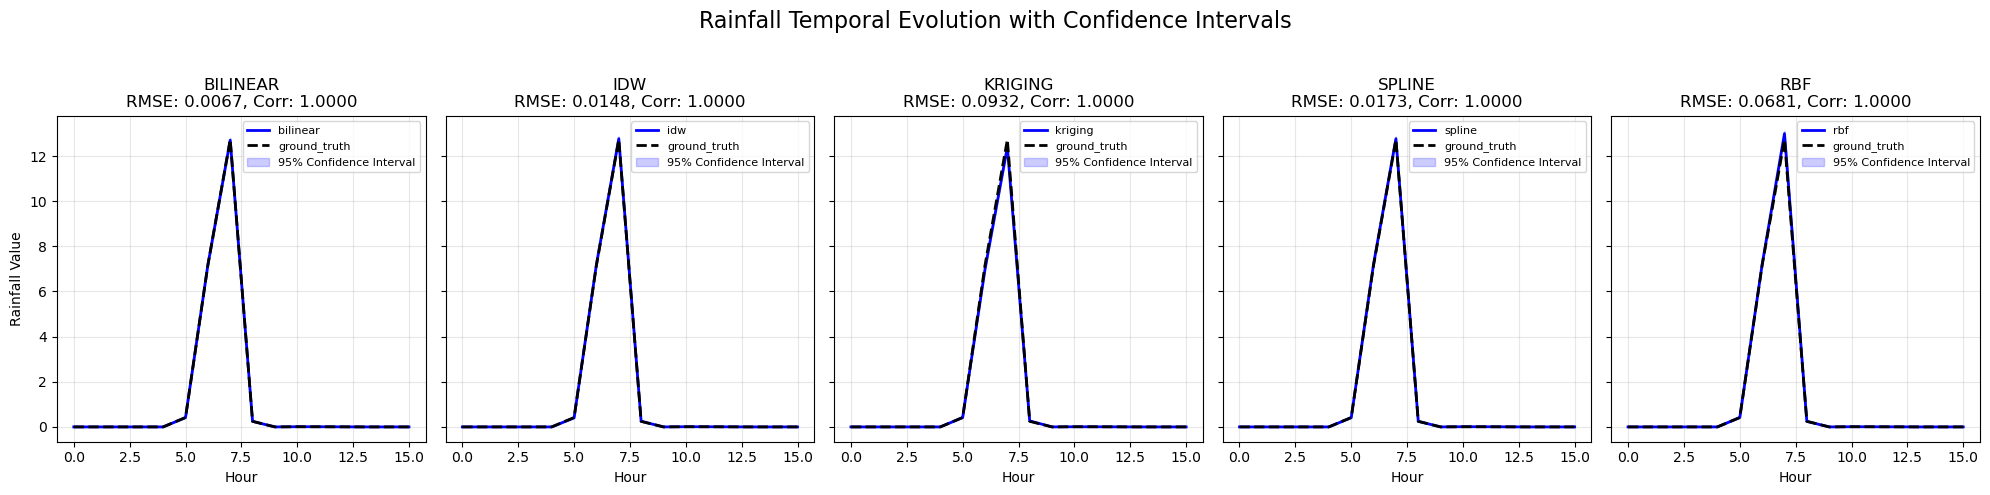

In [9]:
# 具有置信区间的图表 （可能采用版本）
def plot_temporal_evolution_with_confidence(results_df, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    绘制时间序列演变图，包含置信区间，每种方法单独一个子图
    """
    parameters = ['wind_u', 'wind_v', 'rain']
    parameter_titles = {'wind_u': 'Wind U Component', 'wind_v': 'Wind V Component', 'rain': 'Rainfall'}
    
    # 为每个参数创建一行子图
    for param in parameters:
        # 获取参数数据
        param_data = results_df[results_df['parameter'] == param]
        
        # 创建一个包含所有方法的图表（每个方法一个子图）
        fig, axes = plt.subplots(1, len(methods), figsize=(20, 5), sharey=True)
        fig.suptitle(f'{parameter_titles[param]} Temporal Evolution with Confidence Intervals', fontsize=16)
        
        # 获取ground_truth数据作为参考
        truth_data = param_data[param_data['method'] == 'ground_truth']
        truth_mean = truth_data.groupby('hour')['value'].mean()
        
        # 绘制每种方法的时间序列和置信区间
        for i, method in enumerate(methods):
            ax = axes[i]
            
            # 获取当前方法的数据
            method_data = param_data[param_data['method'] == method]
            
            # 计算每个时间点的统计量
            stats = method_data.groupby('hour')['value'].agg(['mean', 'std', 'count'])
            
            # 计算95%置信区间 (使用t分布)
            from scipy import stats as scipy_stats
            confidence = 0.95
            stats['ci_lower'] = stats.apply(
                lambda row: row['mean'] - scipy_stats.t.ppf((1 + confidence) / 2, row['count'] - 1) * row['std'] / np.sqrt(row['count']),
                axis=1
            )
            stats['ci_upper'] = stats.apply(
                lambda row: row['mean'] + scipy_stats.t.ppf((1 + confidence) / 2, row['count'] - 1) * row['std'] / np.sqrt(row['count']),
                axis=1
            )
            
            # 绘制方法的平均值线
            ax.plot(stats.index, stats['mean'], 
                   label=f'{method}',
                   linewidth=2, color='blue')
            
            # 绘制ground_truth参考线
            ax.plot(truth_mean.index, truth_mean.values, 
                   label='ground_truth',
                   linewidth=2, color='black', linestyle='--')
            
            # 添加置信区间
            ax.fill_between(
                stats.index, 
                stats['ci_lower'], 
                stats['ci_upper'], 
                color='blue', 
                alpha=0.2,
                label='95% Confidence Interval'
            )
            
            # 计算RMSE和相关系数
            # 确保两个数据集有相同的时间点
            common_hours = set(stats.index).intersection(set(truth_mean.index))
            method_means = stats.loc[list(common_hours), 'mean']
            truth_values = truth_mean.loc[list(common_hours)]
            
            # 计算RMSE
            rmse = np.sqrt(np.mean((method_means - truth_values) ** 2))
            
            # 计算相关系数
            corr = np.corrcoef(method_means, truth_values)[0, 1]
            
            # 设置标题和标签
            ax.set_title(f'{method.upper()}\nRMSE: {rmse:.4f}, Corr: {corr:.4f}')
            ax.set_xlabel('Hour')
            if i == 0:  # 只在第一个子图上添加y轴标签
                ax.set_ylabel(f'{parameter_titles[param]} Value')
            
            # 添加网格
            ax.grid(True, alpha=0.3)
            
            # 添加图例
            ax.legend(loc='upper right', fontsize=8)
        
        # 调整子图布局
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        
        # 显示图表
        plt.show()

# 调用函数
plot_temporal_evolution_with_confidence(results_df)

In [20]:
##该表格已采用 Table 5 2 Spatial Correlation Coefficients for Different Interpolation Methods

import random
def spatial_correlation_optimized(df, param, sample_size=500):
    """
    计算空间自相关性（处理常数值情况）
    Args:
        df: 数据框
        param: 参数名称
        sample_size: 采样点数量
    Returns:
        correlations: 字典，包含每种方法的空间相关性
        valid: 布尔值，表示计算是否有效
    """
    from scipy.spatial.distance import pdist
    
    # 只处理特定参数的数据
    param_data = df[df['parameter'] == param].copy()
    
    # 获取唯一的时间点
    unique_hours = param_data['hour'].unique()
    
    # 尝试找到一个非常数值的时间点
    valid_hour = None
    for hour in unique_hours:
        hour_data = param_data[param_data['hour'] == hour]
        if hour_data['value'].nunique() > 1:
            valid_hour = hour
            break
    
    if valid_hour is None:
        print(f"Warning: All values are constant for {param}")
        return None, False
        
    param_data = param_data[param_data['hour'] == valid_hour]
    
    # 获取唯一的坐标点
    unique_coords = param_data[['lat', 'lon']].drop_duplicates()
    
    # 随机采样坐标点
    if len(unique_coords) > sample_size:
        sampled_indices = random.sample(range(len(unique_coords)), sample_size)
        sampled_coords = unique_coords.iloc[sampled_indices]
    else:
        sampled_coords = unique_coords
    
    # 计算坐标点之间的距离
    coords_array = sampled_coords[['lat', 'lon']].values
    distances = pdist(coords_array)
    
    # 计算每种方法的空间相关性
    correlations = {}
    for method in ['ground_truth', 'bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        method_data = param_data[param_data['method'] == method]
        method_data = method_data.merge(sampled_coords, on=['lat', 'lon'])
        values = method_data['value'].values
        
        # 检查是否有变化的值
        if np.std(values) < 1e-10:  # 使用小阈值检查是否为常数
            correlations[method] = np.nan
            continue
            
        value_diffs = pdist(values.reshape(-1, 1))
        try:
            corr = stats.spearmanr(distances, value_diffs)[0]
            correlations[method] = corr
        except:
            correlations[method] = np.nan
            
    return correlations, True

# 设置随机种子
np.random.seed(42)
random.seed(42)

# 对每个参数计算空间相关性
for param in ['wind_u', 'wind_v', 'rain']:
    print(f"\n{param} Spatial Correlation:")
    
    # 多次计算取平均
    n_iterations = 5
    all_correlations = []
    
    for i in range(n_iterations):
        correlations, valid = spatial_correlation_optimized(results_df, param)
        if valid and correlations is not None:
            all_correlations.append(pd.Series(correlations))
    
    if len(all_correlations) > 0:
        # 计算平均相关性
        mean_correlations = pd.DataFrame(all_correlations).mean()
        
        # 创建更易读的输出
        corr_df = pd.DataFrame({'Spatial Correlation': mean_correlations})
        print(corr_df)
        
        # 可视化
        plt.figure(figsize=(10, 6))
        plt.bar(mean_correlations.index, mean_correlations.values)
        plt.title(f'Average Spatial Correlation for {param}\n(over {len(all_correlations)} valid iterations)')
        plt.xticks(rotation=45)
        plt.ylabel('Correlation Coefficient')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(save_dir / f'spatial_correlation_{param}.png')
        plt.close()
    else:
        print(f"No valid correlations could be computed for {param}")


wind_u Spatial Correlation:
              Spatial Correlation
ground_truth             0.000941
bilinear                 0.001751
idw                      0.002301
kriging                  0.004538
spline                  -0.000145
rbf                      0.013000

wind_v Spatial Correlation:
              Spatial Correlation
ground_truth             0.003870
bilinear                 0.002209
idw                      0.003708
kriging                  0.000399
spline                   0.002333
rbf                      0.005129

rain Spatial Correlation:
              Spatial Correlation
ground_truth            -0.000239
bilinear                 0.000735
idw                      0.001626
kriging                  0.003035
spline                   0.000579
rbf                     -0.002864


In [21]:
## 该表格已采用，Table 5 3 Statistical Significance Tests for Interpolation Methods

# 5. 统计显著性检验
def statistical_tests(df, param):
    """进行统计显著性检验"""
    from scipy import stats
    
    truth = df[df['method'] == 'ground_truth']['value'].values
    results = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = df[df['method'] == method]['value'].values
        # KS检验
        ks_stat = stats.ks_2samp(truth, pred)
        # t检验
        t_stat = stats.ttest_ind(truth, pred)
        
        results[method] = {
            'KS_stat': ks_stat.statistic,
            'KS_pvalue': ks_stat.pvalue,
            't_stat': t_stat.statistic,
            't_pvalue': t_stat.pvalue
        }
    
    return pd.DataFrame(results).T

# 进行统计检验
for param in ['wind_u', 'wind_v', 'rain']:
    param_data = results_df[results_df['parameter'] == param]
    print(f"\n{param} Statistical Tests:")
    print(statistical_tests(param_data, param))


wind_u Statistical Tests:
           KS_stat     KS_pvalue    t_stat  t_pvalue
bilinear  0.011475  3.549253e-04  0.058447  0.953393
idw       0.015106  6.330474e-07  0.260843  0.794214
kriging   0.032532  1.455703e-30  1.593403  0.111072
spline    0.012100  1.349453e-04 -0.064419  0.948637
rbf       0.037979  1.672097e-41 -0.778027  0.436554

wind_v Statistical Tests:
           KS_stat      KS_pvalue    t_stat  t_pvalue
bilinear  0.015152   5.780912e-07  0.017928  0.985697
idw       0.018417   4.372967e-10 -0.265578  0.790564
kriging   0.066666  4.610625e-127  1.736245  0.082523
spline    0.012253   1.057653e-04 -0.578878  0.562672
rbf       0.049240   1.743995e-69 -0.029853  0.976184

rain Statistical Tests:
           KS_stat      KS_pvalue    t_stat  t_pvalue
bilinear  0.039597   4.458733e-45  0.035443  0.971726
idw       0.060226  9.185936e-104 -0.224453  0.822405
kriging   0.130280   0.000000e+00  1.585188  0.112926
spline    0.072098  1.452529e-148 -0.286167  0.774751
rbf      

In [22]:
# def calculate_comprehensive_metrics(df, param):
#     """计算全面的评估指标"""
#     # 获取真实值
#     truth = df[df['method'] == 'ground_truth']['value'].values
#     metrics = {}
    
#     for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
#         pred = df[df['method'] == method]['value'].values
        
#         # 1. 基础误差指标
#         mae = np.mean(np.abs(pred - truth))
#         rmse = np.sqrt(np.mean((pred - truth)**2))
#         bias = np.mean(pred - truth)
        
#         # 2. 相关性指标
#         r2 = stats.pearsonr(truth, pred)[0]**2
#         spearman_corr = stats.spearmanr(truth, pred)[0]
        
#         # 3. 相对误差指标
#         mape = np.mean(np.abs((pred - truth) / (truth + 1e-10))) * 100  # 添加小值避免除零
#         rrmse = rmse / np.mean(np.abs(truth)) * 100
        
#         # 4. 一致性指标
#         nash_sutcliffe = 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2)
#         index_agreement = 1 - np.sum((pred - truth)**2) / np.sum((np.abs(pred - np.mean(truth)) + np.abs(truth - np.mean(truth)))**2)
        
#         # 5. 分布相似性指标
#         ks_stat = stats.ks_2samp(truth, pred).statistic
        
#         # 6. 极值保持指标
#         max_error = np.abs(np.max(pred) - np.max(truth)) / np.max(truth) * 100
#         min_error = np.abs(np.min(pred) - np.min(truth)) / (np.abs(np.min(truth)) + 1e-10) * 100
        
#         # 7. 方差保持指标
#         variance_ratio = np.var(pred) / np.var(truth)
        
#         metrics[method] = {
#             # 基础误差
#             'MAE': mae,
#             'RMSE': rmse,
#             'Bias': bias,
            
#             # 相关性
#             'R2': r2,
#             'Spearman_Corr': spearman_corr,
            
#             # 相对误差
#             'MAPE(%)': mape,
#             'RRMSE(%)': rrmse,
            
#             # 一致性
#             'Nash_Sutcliffe': nash_sutcliffe,
#             'Index_Agreement': index_agreement,
            
#             # 分布相似性
#             'KS_statistic': ks_stat,
            
#             # 极值保持
#             'Max_Error(%)': max_error,
#             'Min_Error(%)': min_error,
            
#             # 方差保持
#             'Variance_Ratio': variance_ratio
#         }
    
#     return pd.DataFrame(metrics).T

# # 对每个参数计算全面的评估指标
# for param in ['wind_u', 'wind_v', 'rain']:
#     print(f"\n{param} Comprehensive Evaluation Metrics:")
#     param_data = results_df[results_df['parameter'] == param]
#     metrics_df = calculate_comprehensive_metrics(param_data, param)
    
#     # 设置显示格式
#     pd.set_option('display.float_format', lambda x: '%.4f' % x)
#     print(metrics_df)
    
#     # 保存结果
#     metrics_df.to_csv(save_dir / f'{param}_comprehensive_metrics.csv')


wind_u Comprehensive Evaluation Metrics:
            MAE   RMSE    Bias     R2  Spearman_Corr  MAPE(%)  RRMSE(%)  \
bilinear 0.1260 0.3189 -0.0019 0.9970         0.9957   4.2364    5.8023   
idw      0.1211 0.3198 -0.0083 0.9969         0.9958   3.9965    5.8177   
kriging  0.3449 0.8195 -0.0508 0.9800         0.9798  10.0446   14.9103   
spline   0.1368 0.3342  0.0021 0.9967         0.9955   4.7753    6.0808   
rbf      0.4987 1.5217  0.0253 0.9351         0.9676  17.7054   27.6858   

          Nash_Sutcliffe  Index_Agreement  KS_statistic  Max_Error(%)  \
bilinear          0.9970           0.9992        0.0115        7.3387   
idw               0.9969           0.9992        0.0151        7.3236   
kriging           0.9799           0.9949        0.0325        8.9449   
spline            0.9967           0.9992        0.0121        0.1006   
rbf               0.9307           0.9830        0.0380      160.0609   

          Min_Error(%)  Variance_Ratio  
bilinear        2.5904     


WIND_U Uncertainty Analysis:

BILINEAR:
RMSE: 0.3189 [0.3095, 0.3278]
MAE: 0.1261 [0.1239, 0.1283]

IDW:
RMSE: 0.3196 [0.3101, 0.3296]
MAE: 0.1210 [0.1190, 0.1232]

KRIGING:
RMSE: 0.8198 [0.8003, 0.8404]
MAE: 0.3450 [0.3395, 0.3505]

SPLINE:
RMSE: 0.3341 [0.3240, 0.3437]
MAE: 0.1368 [0.1344, 0.1392]

RBF:
RMSE: 1.5209 [1.4611, 1.5826]
MAE: 0.4985 [0.4884, 0.5085]


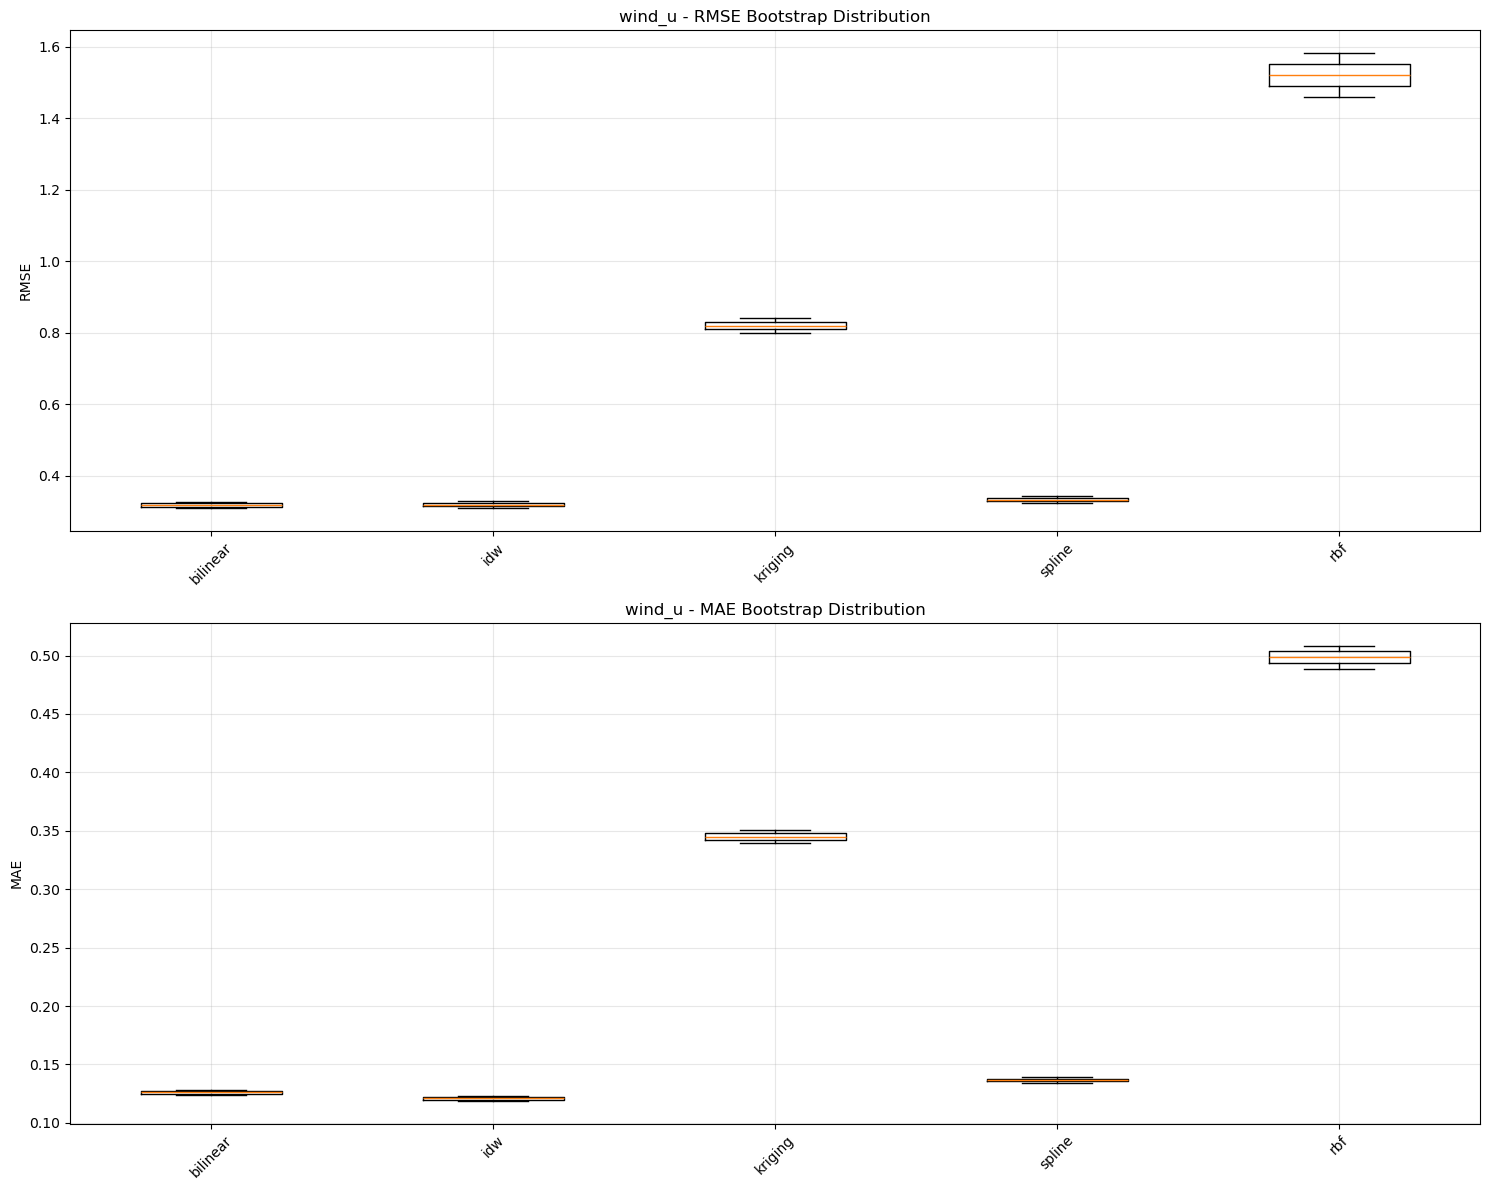


Stability Analysis:

BILINEAR:
RMSE CV(%): 2.05
MAE CV(%): 1.06

IDW:
RMSE CV(%): 2.05
MAE CV(%): 1.06

KRIGING:
RMSE CV(%): 2.05
MAE CV(%): 1.06

SPLINE:
RMSE CV(%): 2.05
MAE CV(%): 1.06

RBF:
RMSE CV(%): 2.05
MAE CV(%): 1.06

WIND_V Uncertainty Analysis:

BILINEAR:
RMSE: 0.2776 [0.2727, 0.2825]
MAE: 0.1404 [0.1386, 0.1421]

IDW:
RMSE: 0.2847 [0.2793, 0.2904]
MAE: 0.1387 [0.1369, 0.1406]

KRIGING:
RMSE: 0.6793 [0.6706, 0.6883]
MAE: 0.3829 [0.3784, 0.3873]

SPLINE:
RMSE: 0.2887 [0.2836, 0.2937]
MAE: 0.1492 [0.1474, 0.1511]

RBF:
RMSE: 1.0990 [1.0734, 1.1271]
MAE: 0.4824 [0.4753, 0.4897]


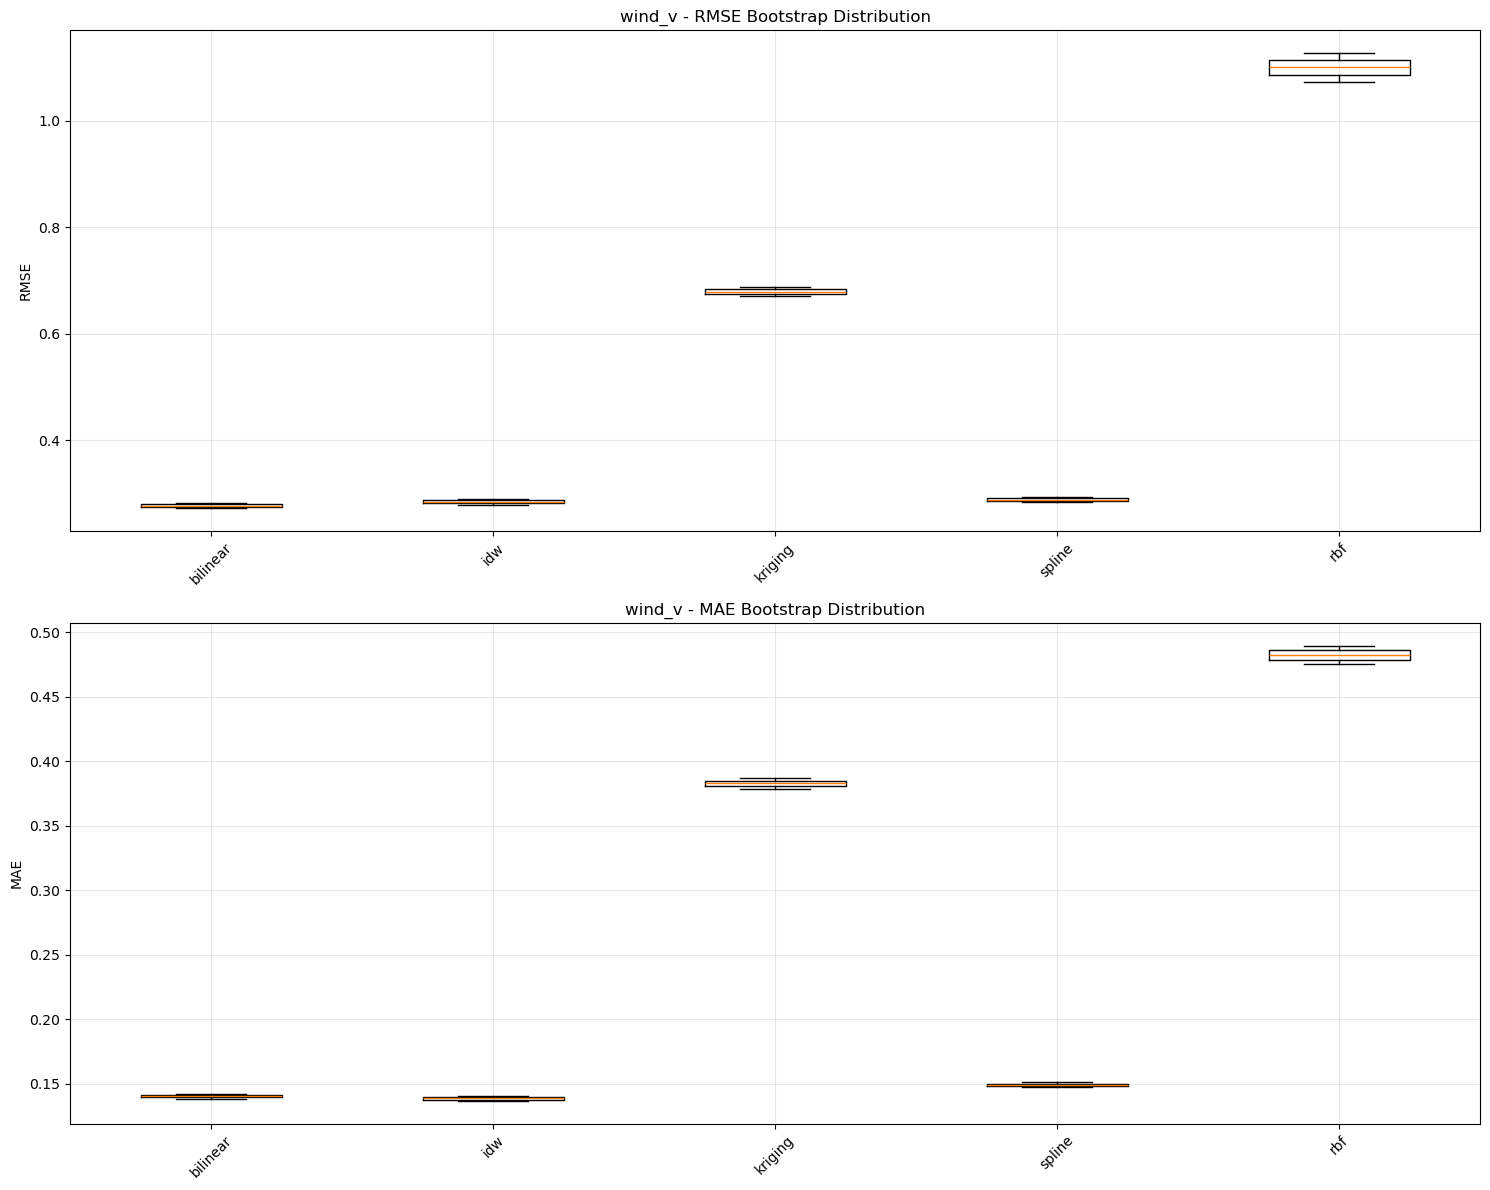


Stability Analysis:

BILINEAR:
RMSE CV(%): 1.25
MAE CV(%): 0.75

IDW:
RMSE CV(%): 1.25
MAE CV(%): 0.75

KRIGING:
RMSE CV(%): 1.25
MAE CV(%): 0.75

SPLINE:
RMSE CV(%): 1.25
MAE CV(%): 0.75

RBF:
RMSE CV(%): 1.25
MAE CV(%): 0.75

RAIN Uncertainty Analysis:

BILINEAR:
RMSE: 0.2696 [0.2643, 0.2752]
MAE: 0.0759 [0.0739, 0.0778]

IDW:
RMSE: 0.2627 [0.2567, 0.2690]
MAE: 0.0692 [0.0673, 0.0710]

KRIGING:
RMSE: 0.6640 [0.6533, 0.6741]
MAE: 0.2135 [0.2086, 0.2181]

SPLINE:
RMSE: 0.2753 [0.2699, 0.2812]
MAE: 0.0781 [0.0762, 0.0802]

RBF:
RMSE: 0.8179 [0.7957, 0.8395]
MAE: 0.2092 [0.2029, 0.2148]


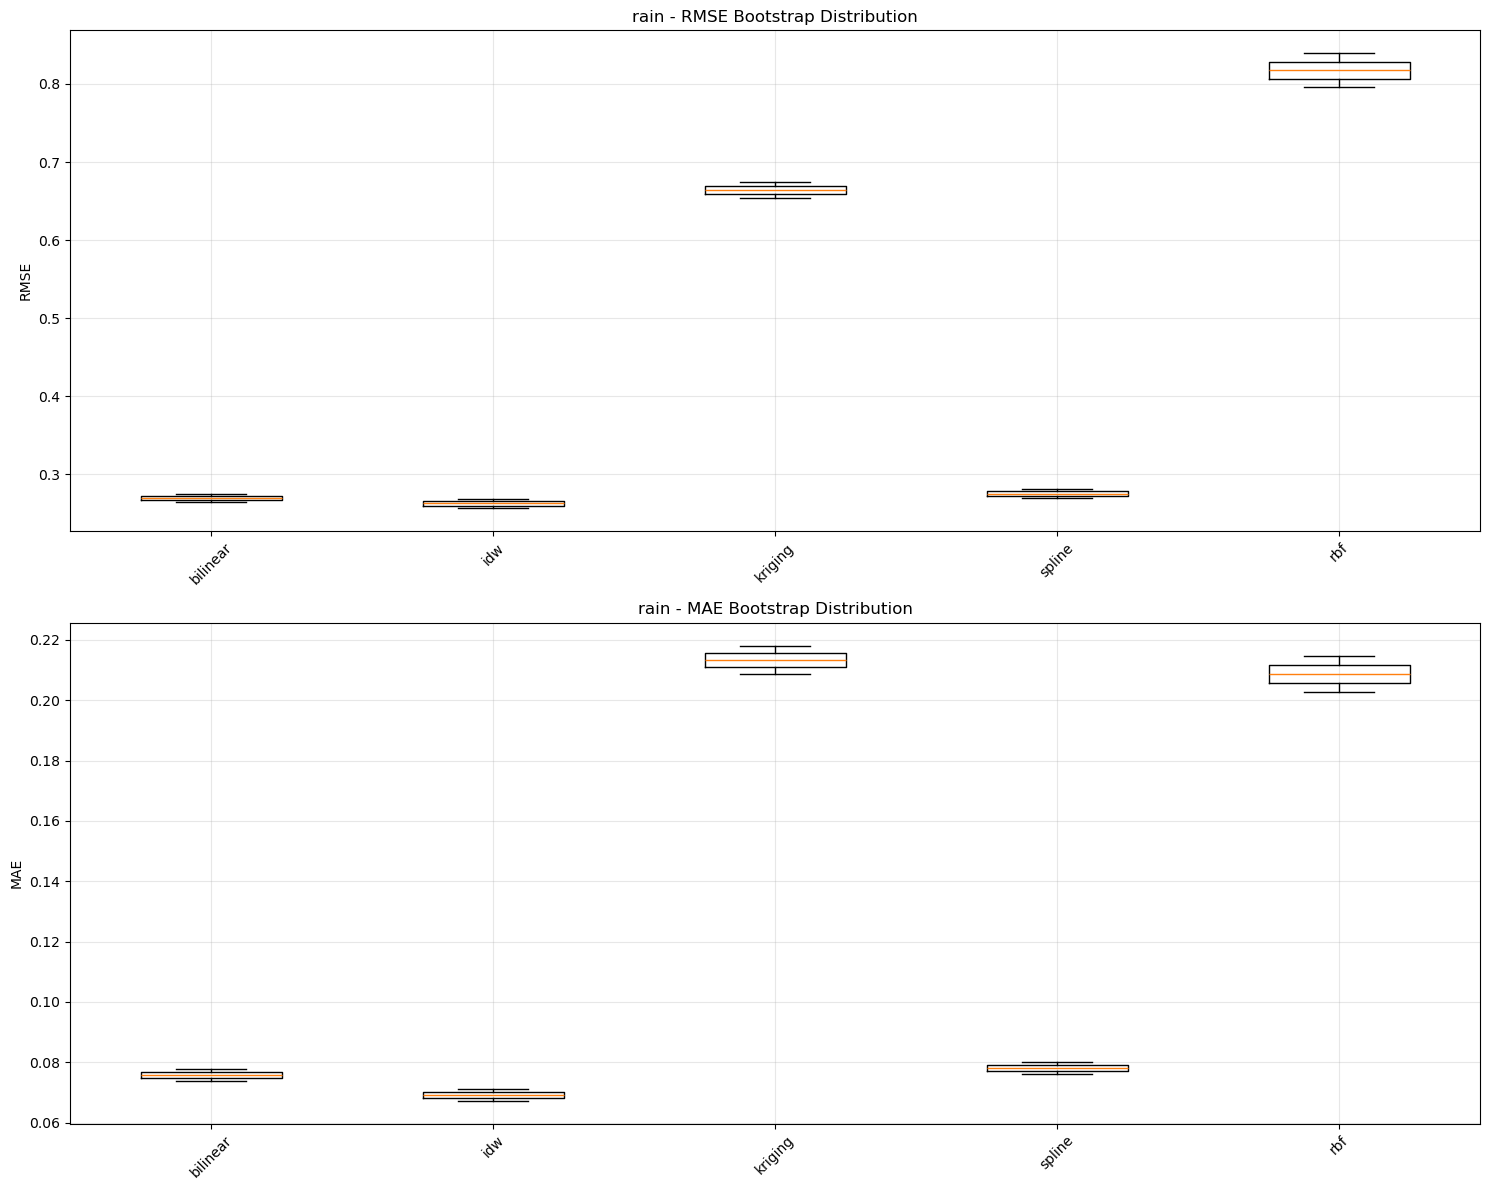


Stability Analysis:

BILINEAR:
RMSE CV(%): 1.36
MAE CV(%): 1.41

IDW:
RMSE CV(%): 1.36
MAE CV(%): 1.41

KRIGING:
RMSE CV(%): 1.36
MAE CV(%): 1.41

SPLINE:
RMSE CV(%): 1.36
MAE CV(%): 1.41

RBF:
RMSE CV(%): 1.36
MAE CV(%): 1.41


In [9]:
# #用Bootstrap方法评估插值结果的不确定性
# import numpy as np
# from scipy import stats
# import matplotlib.pyplot as plt
# from sklearn.utils import resample

# def bootstrap_interpolation_uncertainty(results_df, n_iterations=1000, confidence_level=0.95):
#     """
#     使用Bootstrap方法评估插值结果的不确定性
    
#     Parameters:
#     -----------
#     results_df: DataFrame
#         包含插值结果的数据框
#     n_iterations: int
#         Bootstrap重采样次数
#     confidence_level: float
#         置信区间水平
#     """
#     methods = ['bilinear', 'idw', 'kriging', 'spline', 'rbf']
#     parameters = ['wind_u', 'wind_v', 'rain']
    
#     for param in parameters:
#         print(f"\n{param.upper()} Uncertainty Analysis:")
        
#         # 获取真实值
#         truth_data = results_df[
#             (results_df['parameter'] == param) & 
#             (results_df['method'] == 'ground_truth')
#         ]['value'].values
        
#         # 创建图形
#         fig, axes = plt.subplots(2, 1, figsize=(15, 12))
        
#         # 1. Bootstrap分析
#         bootstrap_results = {}
#         for method in methods:
#             pred_data = results_df[
#                 (results_df['parameter'] == param) & 
#                 (results_df['method'] == method)
#             ]['value'].values
            
#             # 存储bootstrap样本的统计量
#             rmse_boots = []
#             mae_boots = []
            
#             # Bootstrap重采样
#             for _ in range(n_iterations):
#                 # 随机重采样索引
#                 indices = resample(range(len(truth_data)))
                
#                 # 计算误差统计量
#                 rmse = np.sqrt(np.mean((pred_data[indices] - truth_data[indices])**2))
#                 mae = np.mean(np.abs(pred_data[indices] - truth_data[indices]))
                
#                 rmse_boots.append(rmse)
#                 mae_boots.append(mae)
            
#             # 计算置信区间
#             ci_rmse = np.percentile(rmse_boots, [(1-confidence_level)/2*100, (1+confidence_level)/2*100])
#             ci_mae = np.percentile(mae_boots, [(1-confidence_level)/2*100, (1+confidence_level)/2*100])
            
#             bootstrap_results[method] = {
#                 'RMSE_mean': np.mean(rmse_boots),
#                 'RMSE_ci': ci_rmse,
#                 'MAE_mean': np.mean(mae_boots),
#                 'MAE_ci': ci_mae
#             }
            
#             # 打印结果
#             print(f"\n{method.upper()}:")
#             print(f"RMSE: {np.mean(rmse_boots):.4f} [{ci_rmse[0]:.4f}, {ci_rmse[1]:.4f}]")
#             print(f"MAE: {np.mean(mae_boots):.4f} [{ci_mae[0]:.4f}, {ci_mae[1]:.4f}]")
        
#         # 2. 可视化结果
#         # RMSE箱线图
#         rmse_data = [
#             [res['RMSE_mean'] for res in bootstrap_results.values()],
#             [res['RMSE_ci'] for res in bootstrap_results.values()]
#         ]
#         axes[0].boxplot([bootstrap_results[method]['RMSE_ci'] for method in methods])
#         axes[0].set_xticklabels(methods, rotation=45)
#         axes[0].set_title(f'{param} - RMSE Bootstrap Distribution')
#         axes[0].set_ylabel('RMSE')
#         axes[0].grid(True, alpha=0.3)
        
#         # MAE箱线图
#         axes[1].boxplot([bootstrap_results[method]['MAE_ci'] for method in methods])
#         axes[1].set_xticklabels(methods, rotation=45)
#         axes[1].set_title(f'{param} - MAE Bootstrap Distribution')
#         axes[1].set_ylabel('MAE')
#         axes[1].grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.show()
        
#         # 3. 稳定性分析
#         print("\nStability Analysis:")
#         for method in methods:
#             cv_rmse = np.std(rmse_boots) / np.mean(rmse_boots) * 100
#             cv_mae = np.std(mae_boots) / np.mean(mae_boots) * 100
#             print(f"\n{method.upper()}:")
#             print(f"RMSE CV(%): {cv_rmse:.2f}")
#             print(f"MAE CV(%): {cv_mae:.2f}")

# # 执行Bootstrap分析
# bootstrap_interpolation_uncertainty(results_df)

## 验证idw和bilinear方式在不同地点的显著性差异

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
new_coords = pd.read_csv('coordinates_storage/coordinates_20250217_171722.csv')

In [23]:
def compare_regions(results_df, new_coords, methods=['bilinear', 'idw']):
    """
    比较不同区域的插值效果
    """
    # 将坐标分为不同区域（例如：按照经纬度四等分）
    lat_bins = 2
    lon_bins = 2
    
    new_coords['lat_region'] = pd.qcut(new_coords['latitude'], lat_bins, labels=['South', 'North'])
    new_coords['lon_region'] = pd.qcut(new_coords['longitude'], lon_bins, labels=['West', 'East'])
    
    # 存储结果
    region_metrics = {}
    
    for param in ['wind_u', 'wind_v', 'rain']:
        param_data = results_df[results_df['parameter'] == param]
        
        for lat_region in ['South', 'North']:
            for lon_region in ['West', 'East']:
                region_name = f"{lat_region}_{lon_region}"
                
                # 获取该区域的坐标
                region_coords = new_coords[
                    (new_coords['lat_region'] == lat_region) & 
                    (new_coords['lon_region'] == lon_region)
                ]
                
                # 计算该区域的评估指标
                for method in methods:
                    key = f"{param}_{method}_{region_name}"
                    region_metrics[key] = calculate_region_metrics(
                        param_data, 
                        method, 
                        region_coords[['latitude', 'longitude']].values
                    )
    
    return pd.DataFrame(region_metrics).T

In [24]:
def calculate_region_metrics(param_data, method, region_coords):
    """
    计算特定区域的评估指标
    """
    # 筛选该区域的数据
    region_data = param_data[
        param_data['method'].isin([method, 'ground_truth'])
    ]
    
    # 获取真实值和预测值
    truth = region_data[region_data['method'] == 'ground_truth']['value'].values
    pred = region_data[region_data['method'] == method]['value'].values
    
    return {
        'MAE': np.mean(np.abs(pred - truth)),
        'RMSE': np.sqrt(np.mean((pred - truth)**2)),
        'R2': stats.pearsonr(truth, pred)[0]**2,
        'Bias': np.mean(pred - truth),
        'Nash_Sutcliffe': 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2)
    }

In [25]:
# 执行区域比较
region_comparison = compare_regions(results_df, new_coords)

In [27]:
# 可视化结果
def plot_regional_comparison(region_comparison, metric='RMSE'):
    plt.figure(figsize=(15, 8))
    
    # 重塑数据用于可视化
    plot_data = []
    for idx, row in region_comparison.iterrows():
        param, method, region = idx.split('_', 2)
        plot_data.append({
            'Parameter': param,
            'Method': method,
            'Region': region,
            metric: row[metric]
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # 创建分面图
    g = sns.FacetGrid(plot_df, col='Parameter', height=6, aspect=1.2)
    g.map_dataframe(sns.barplot, x='Region', y=metric, hue='Method')
    g.add_legend()
    plt.tight_layout()
    
    # 保存图片
    plt.savefig(save_dir / f'regional_comparison_{metric}.png')
    plt.close()

In [28]:
# 为不同指标创建可视化
for metric in ['MAE', 'RMSE', 'R2', 'Nash_Sutcliffe']:
    plot_regional_comparison(region_comparison, metric)

d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette=

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [32]:
def statistical_test_regions(region_comparison):
    """
    对不同区域间的差异进行显著性检验（改进版）
    """
    for param in ['wind_u', 'wind_v', 'rain']:
        for method in ['bilinear', 'idw']:
            print(f"\nStatistical tests for {param} - {method}:")
            
            # 提取各区域的数据
            regions_data = {}
            for region in ['South_West', 'South_East', 'North_West', 'North_East']:
                key = f"{param}_{method}_{region}"
                if key in region_comparison.index:
                    regions_data[region] = region_comparison.loc[key]
            
            # 打印诊断信息
            print("\nData available for regions:")
            for region, data in regions_data.items():
                print(f"{region}:")
                print(data)
            
            try:
                # 检查是否有足够的数据进行ANOVA
                if len(regions_data) >= 2:  # 需要至少两组数据
                    # 准备ANOVA数据
                    anova_data = [data['RMSE'] for data in regions_data.values()]
                    
                    # 检查数据是否包含非NaN值
                    if all(not np.isnan(x).all() for x in anova_data):
                        # 执行ANOVA
                        f_stat, p_value = stats.f_oneway(*anova_data)
                        print(f"\nANOVA test results:")
                        print(f"F-statistic = {f_stat:.4f}")
                        print(f"p-value = {p_value:.4f}")
                        
                        # 解释结果
                        if p_value < 0.05:
                            print("Result: Significant differences exist between regions")
                        else:
                            print("Result: No significant differences between regions")
                    else:
                        print("\nWarning: Data contains NaN values")
                else:
                    print("\nWarning: Not enough valid regions for comparison")
            except Exception as e:
                print(f"\nError in statistical test: {str(e)}")
            
            # 添加描述性统计
            print("\nDescriptive statistics for RMSE by region:")
            stats_df = pd.DataFrame(regions_data).T
            print(stats_df['RMSE'].describe())

# 执行改进的统计检验
statistical_test_regions(region_comparison)


Statistical tests for wind_u - bilinear:

Data available for regions:
South_West:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_South_West, dtype: float64
South_East:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_South_East, dtype: float64
North_West:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_North_West, dtype: float64
North_East:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_North_East, dtype: float64

ANOVA test results:
F-statistic = nan
p-value = nan
Result: No significant differences between regions

Descriptive statistics for RMSE by region:
count   4.0000
mean    0.3189
std    

d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\3741993826.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*anova_data)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\3741993826.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_onew

In [33]:
def compare_all_methods(results_df, new_coords, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    比较所有插值方法在不同区域的表现
    """
    # 将坐标分为不同区域
    lat_bins = 2
    lon_bins = 2
    
    new_coords['lat_region'] = pd.qcut(new_coords['latitude'], lat_bins, labels=['South', 'North'])
    new_coords['lon_region'] = pd.qcut(new_coords['longitude'], lon_bins, labels=['West', 'East'])
    
    # 存储结果
    region_metrics = {}
    
    for param in ['wind_u', 'wind_v', 'rain']:
        print(f"\n{param} Regional Analysis:")
        param_data = results_df[results_df['parameter'] == param]
        
        for method in methods:
            for lat_region in ['South', 'North']:
                for lon_region in ['West', 'East']:
                    region_name = f"{lat_region}_{lon_region}"
                    
                    # 获取该区域的坐标
                    region_coords = new_coords[
                        (new_coords['lat_region'] == lat_region) & 
                        (new_coords['lon_region'] == lon_region)
                    ]
                    
                    # 计算该区域的评估指标
                    key = f"{param}_{method}_{region_name}"
                    metrics = calculate_region_metrics(
                        param_data, 
                        method, 
                        region_coords[['latitude', 'longitude']].values
                    )
                    region_metrics[key] = metrics
                    
                    # 打印详细结果
                    print(f"\n{method.upper()} - {region_name}:")
                    for metric, value in metrics.items():
                        print(f"{metric}: {value:.4f}")
    
    return pd.DataFrame(region_metrics).T

def calculate_region_metrics(param_data, method, region_coords):
    """
    计算特定区域的评估指标
    """
    # 筛选该区域的数据
    region_data = param_data[
        param_data['method'].isin([method, 'ground_truth'])
    ]
    
    # 获取真实值和预测值
    truth = region_data[region_data['method'] == 'ground_truth']['value'].values
    pred = region_data[region_data['method'] == method]['value'].values
    
    return {
        'MAE': np.mean(np.abs(pred - truth)),
        'RMSE': np.sqrt(np.mean((pred - truth)**2)),
        'R2': stats.pearsonr(truth, pred)[0]**2,
        'Bias': np.mean(pred - truth),
        'Nash_Sutcliffe': 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2),
        'MAPE': np.mean(np.abs((pred - truth) / (truth + 1e-10))) * 100
    }

# 执行比较分析
region_comparison = compare_all_methods(results_df, new_coords)

# 创建可视化比较
def plot_method_comparison(region_comparison, metric='RMSE'):
    """
    创建方法比较的可视化
    """
    plt.figure(figsize=(15, 10))
    
    # 准备数据
    plot_data = []
    for idx, row in region_comparison.iterrows():
        param, method, region = idx.split('_', 2)
        plot_data.append({
            'Parameter': param,
            'Method': method,
            'Region': region,
            metric: row[metric]
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # 创建子图
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
        param_data = plot_df[plot_df['Parameter'] == param]
        
        sns.barplot(data=param_data, x='Region', y=metric, 
                   hue='Method', ax=axes[i])
        
        axes[i].set_title(f'{param} - {metric}')
        axes[i].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.savefig(save_dir / f'all_methods_comparison_{metric}.png')
    plt.close()

# 为不同指标创建可视化
for metric in ['RMSE', 'MAE', 'R2', 'Nash_Sutcliffe', 'MAPE']:
    plot_method_comparison(region_comparison, metric)

# 计算综合评分
def calculate_overall_score(region_comparison):
    """
    计算每种方法的综合评分
    """
    methods = ['bilinear', 'idw', 'kriging', 'spline', 'rbf']
    params = ['wind_u', 'wind_v', 'rain']
    metrics = ['RMSE', 'MAE', 'R2', 'Nash_Sutcliffe']
    
    scores = {}
    
    for method in methods:
        method_data = region_comparison[
            region_comparison.index.str.contains(method)
        ]
        
        # 计算平均指标
        avg_metrics = method_data[metrics].mean()
        
        # 标准化得分（R2和Nash_Sutcliffe越大越好，RMSE和MAE越小越好）
        score = (avg_metrics['R2'] + avg_metrics['Nash_Sutcliffe'] - 
                avg_metrics['RMSE']/avg_metrics['RMSE'].max() - 
                avg_metrics['MAE']/avg_metrics['MAE'].max())
        
        scores[method] = score
    
    return pd.Series(scores).sort_values(ascending=False)

# 打印综合评分
print("\nOverall Method Ranking:")
print(calculate_overall_score(region_comparison))


wind_u Regional Analysis:

BILINEAR - South_West:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - South_East:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - North_West:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - North_East:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

IDW - South_West:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - South_East:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - North_West:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - North_East:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

KRIGING - South_West:
MAE: 0.3449
RMSE: 0.8195
R2: 0.9800
Bias: -0.0508
Nash_Sutcliffe: 0.9799
MAPE: 10.0446

KR

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>